# Week 2 Assignment – End-to-End ML Pipeline: Tesla Deliveries & Production (2015–2025)

**Dataset:** [Tesla EA Deliveries and Production Data (2015–2025) – Kaggle](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

**Objective:** Predict **vehicle price** (Avg_Price_USD) using vehicle attributes and temporal features — covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting on sales/price data.

---


## 1. Imports & Setup

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("muted")


## 2. Data Loading & Overview

The raw dataset has **2,640 rows** — each row is a unique combination of Year × Month × Region × Model.
Columns include production units, estimated deliveries, pricing, range, battery capacity, CO₂ savings, and charging station counts.

Key data-quality flag: `Source_Type` distinguishes official quarterly figures from interpolated monthly and regionally estimated values.


In [56]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "tesla_deliveries_dataset_2015_2025.csv"

# Load the latest version
df_raw = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nalisha/tesla-ea-deliveries-and-production-data20152025",
  file_path,
)
print("First 5 records:")

df_raw = df_raw.sort_values(["Year", "Month", "Region", "Model"]).reset_index(drop=True)


print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)

df_raw.head(5)

First 5 records:
Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626
2,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281
3,2015,1,Asia,Model X,7292,7298,107082.30,120,702,767.85,Estimated (Region),11748
4,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390


In [57]:
print("Unique values per categorical column:")
print("  Years:        ", sorted(df_raw["Year"].unique()))
print("  Months:       ", sorted(df_raw["Month"].unique()))
print("  Regions:      ", df_raw["Region"].unique().tolist())
print("  Models:       ", df_raw["Model"].unique().tolist())
print("  Source types: ", df_raw["Source_Type"].unique().tolist())
print()
print("Rows per Source_Type:")
print(df_raw["Source_Type"].value_counts())
print()
print("Rows per year:", df_raw.groupby("Year").size().to_dict())


Unique values per categorical column:
  Years:         [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Months:        [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  Regions:       ['Asia', 'Europe', 'Middle East', 'North America']
  Models:        ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
  Source types:  ['Estimated (Region)', 'Official (Quarter)', 'Interpolated (Month)']

Rows per Source_Type:
Source_Type
Official (Quarter)      884
Interpolated (Month)    884
Estimated (Region)      872
Name: count, dtype: int64

Rows per year: {2015: 240, 2016: 240, 2017: 240, 2018: 240, 2019: 240, 2020: 240, 2021: 240, 2022: 240, 2023: 240, 2024: 240, 2025: 240}


In [58]:
print("Basic statistics:")
df_raw.describe().round(1)


Basic statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.0,2640.0,2640.0,2640.0,2640.0,2640.0,2640.0,2640.0,2640.0
mean,2020.0,6.5,9922.2,10655.8,84907.3,87.1,500.3,744.1,8932.1
std,3.2,3.5,3936.0,4260.6,20123.3,20.8,120.9,353.2,3469.6
min,2015.0,1.0,48.0,50.0,50003.7,60.0,330.0,3.1,3002.0
25%,2017.0,3.8,7292.0,7828.2,67726.4,75.0,418.0,499.6,5897.8
50%,2020.0,6.5,9857.0,10546.5,85058.5,82.0,470.0,699.5,8901.5
75%,2023.0,9.2,12510.2,13469.0,102373.0,100.0,586.2,943.8,11938.0
max,2025.0,12.0,25704.0,28939.0,119965.4,120.0,719.0,2548.6,14996.0


## 3. Data Preprocessing & Aggregation

We build five aggregated views for EDA while retaining raw row-level data for ML.

**Aggregation rules:**
- Volume columns (`Production`, `Deliveries`, `CO2`) → **sum**
- Attribute columns (`Price`, `Range`, `Battery`) → **mean**

Quarter mapping: Q1 = Jan–Mar, Q2 = Apr–Jun, Q3 = Jul–Sep, Q4 = Oct–Dec.


In [59]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]
print("Any negative values:", (df_raw[num_cols] < 0).any().any())


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Any negative values: False


In [60]:
# Date & quarter labels
df_raw["Date"]    = pd.to_datetime(df_raw[["Year", "Month"]].assign(day=1))
df_raw["Quarter"] = df_raw["Date"].dt.to_period("Q").astype(str)
df_raw["Qtr"]     = df_raw["Quarter"].str[-2:]

# Verify quarter completeness
months_per_q = df_raw.groupby("Quarter")["Month"].nunique()
rows_per_q   = df_raw.groupby("Quarter").size()
print("Months per quarter — unique counts:", months_per_q.value_counts().to_dict(), "(all should be 3)")
print("Rows per quarter   — unique counts:", rows_per_q.value_counts().to_dict(),   "(all should be 60)")


Months per quarter — unique counts: {3: 44} (all should be 3)
Rows per quarter   — unique counts: {60: 44} (all should be 60)


In [61]:
#View 1: Overall quarterly
df = df_raw.groupby("Quarter").agg(
    Production        = ("Production_Units",     "sum"),
    Deliveries        = ("Estimated_Deliveries", "sum"),
    Avg_Price         = ("Avg_Price_USD",         "mean"),
    Avg_Range         = ("Range_km",              "mean"),
    CO2_Saved         = ("CO2_Saved_tons",        "sum"),
    Charging_Stations = ("Charging_Stations",     "mean"),
).reset_index()
df["Year"] = df["Quarter"].str[:4].astype(int)
df["Qtr"]  = df["Quarter"].str[-2:]
df["T"]    = range(len(df))
df["Delivery_Rate"]  = (df["Deliveries"] / df["Production"]).round(4)
df["Production_Gap"] = df["Production"] - df["Deliveries"]
df["Prod_QoQ"]       = df["Production"].pct_change().round(4)
df["Del_QoQ"]        = df["Deliveries"].pct_change().round(4)
df["Prod_Rolling4"]  = df["Production"].rolling(4).mean().round(0)
df["Del_Rolling4"]   = df["Deliveries"].rolling(4).mean().round(0)

#View 2: Quarterly per region
region_q = df_raw.groupby(["Quarter", "Region"]).agg(
    Production = ("Production_Units",     "sum"),
    Deliveries = ("Estimated_Deliveries", "sum"),
    Avg_Price  = ("Avg_Price_USD",        "mean"),
    Avg_Range  = ("Range_km",             "mean"),
    CO2_Saved  = ("CO2_Saved_tons",       "sum"),
).reset_index()
region_q["Year"] = region_q["Quarter"].str[:4].astype(int)
region_q["Qtr"]  = region_q["Quarter"].str[-2:]
region_q["Delivery_Rate"]  = (region_q["Deliveries"] / region_q["Production"]).round(4)
region_q["Production_Gap"] = region_q["Production"] - region_q["Deliveries"]

# View 3: Quarterly per model
model_q = df_raw.groupby(["Quarter", "Model"]).agg(
    Production = ("Production_Units",     "sum"),
    Deliveries = ("Estimated_Deliveries", "sum"),
    Avg_Price  = ("Avg_Price_USD",        "mean"),
    Avg_Range  = ("Range_km",             "mean"),
).reset_index()
model_q["Year"] = model_q["Quarter"].str[:4].astype(int)
model_q["Qtr"]  = model_q["Quarter"].str[-2:]

#View 4: Monthly per region
monthly_region = df_raw.groupby(["Year", "Month", "Region"]).agg(
    Production = ("Production_Units",     "sum"),
    Deliveries = ("Estimated_Deliveries", "sum"),
    Avg_Price  = ("Avg_Price_USD",        "mean"),
).reset_index()
monthly_region["Date"] = pd.to_datetime(monthly_region[["Year", "Month"]].assign(day=1))

#View 5: Monthly per model
monthly_model = df_raw.groupby(["Year", "Month", "Model"]).agg(
    Production = ("Production_Units",     "sum"),
    Deliveries = ("Estimated_Deliveries", "sum"),
).reset_index()
monthly_model["Date"] = pd.to_datetime(monthly_model[["Year", "Month"]].assign(day=1))

print("Overall quarterly:  ", df.shape)
print("Region quarterly:   ", region_q.shape)
print("Model quarterly:    ", model_q.shape)
print("Monthly per region: ", monthly_region.shape)
print("Monthly per model:  ", monthly_model.shape)


Overall quarterly:   (44, 16)
Region quarterly:    (176, 11)
Model quarterly:     (220, 8)
Monthly per region:  (528, 7)
Monthly per model:   (660, 6)


In [62]:
df.head()

,Quarter,Production,Deliveries,Avg_Price,Avg_Range,CO2_Saved,Charging_Stations,Year,Qtr,T,Delivery_Rate,Production_Gap,Prod_QoQ,Del_QoQ,Prod_Rolling4,Del_Rolling4
0,2015Q1,572063,532800,84156.452000,492.083333,38900.25,8779.233333,2015,Q1,0,0.9314,39263,NaN,NaN,NaN,NaN
1,2015Q2,652164,608674,84665.328833,529.283333,48878.59,9862.616667,2015,Q2,1,0.9333,43490,0.1400,0.1424,NaN,NaN
2,2015Q3,615982,580430,86931.467167,509.033333,44217.49,9574.400000,2015,Q3,2,0.9423,35552,-0.0555,-0.0464,NaN,NaN
3,2015Q4,705486,653363,86984.156667,509.500000,50469.82,8859.800000,2015,Q4,3,0.9261,52123,0.1453,0.1257,636424.0,593817.0
4,2016Q1,644507,600877,79474.845500,505.666667,46348.41,8844.383333,2016,Q1,4,0.9323,43630,-0.0864,-0.0803,654535.0,610836.0


In [63]:
region_q.head(8)

,Quarter,Region,Production,Deliveries,Avg_Price,Avg_Range,CO2_Saved,Year,Qtr,Delivery_Rate,Production_Gap
0,2015Q1,Asia,187217,173940,77272.775333,471.933333,11804.90,2015,Q1,0.9291,13277
1,2015Q1,Europe,113765,106110,85974.507333,548.266667,8761.74,2015,Q1,0.9327,7655
2,2015Q1,Middle East,124774,117270,84762.246000,460.533333,8435.05,2015,Q1,0.9399,7504
3,2015Q1,North America,146307,135480,88616.279333,487.600000,9898.56,2015,Q1,0.9260,10827
4,2015Q2,Asia,152511,142432,89295.364000,533.200000,11721.62,2015,Q2,0.9339,10079
5,2015Q2,Europe,168478,156633,87961.649333,509.400000,12055.07,2015,Q2,0.9297,11845
6,2015Q2,Middle East,165315,152582,82591.731333,535.400000,12368.13,2015,Q2,0.9230,12733
7,2015Q2,North America,165860,157027,78812.570667,539.133333,12733.77,2015,Q2,0.9467,8833


In [64]:
model_q.head(10)

,Quarter,Model,Production,Deliveries,Avg_Price,Avg_Range,Year,Qtr
0,2015Q1,Cybertruck,101780,93068,85427.451667,482.750000,2015,Q1
1,2015Q1,Model 3,120870,112051,81588.826667,475.916667,2015,Q1
2,2015Q1,Model S,123336,115066,96814.230000,456.666667,2015,Q1
3,2015Q1,Model X,94145,89699,85772.622500,509.166667,2015,Q1
4,2015Q1,Model Y,131932,122916,71179.129167,535.916667,2015,Q1
5,2015Q2,Cybertruck,128316,118904,86387.831667,471.166667,2015,Q2
6,2015Q2,Model 3,143185,131077,80159.400000,572.916667,2015,Q2
7,2015Q2,Model S,149629,140213,77051.677500,604.333333,2015,Q2
8,2015Q2,Model X,119119,110556,92116.001667,524.500000,2015,Q2
9,2015Q2,Model Y,111915,107924,87611.733333,473.500000,2015,Q2


## 4. Exploratory Data Analysis

### 4.1 Overall Quarterly Production & Deliveries

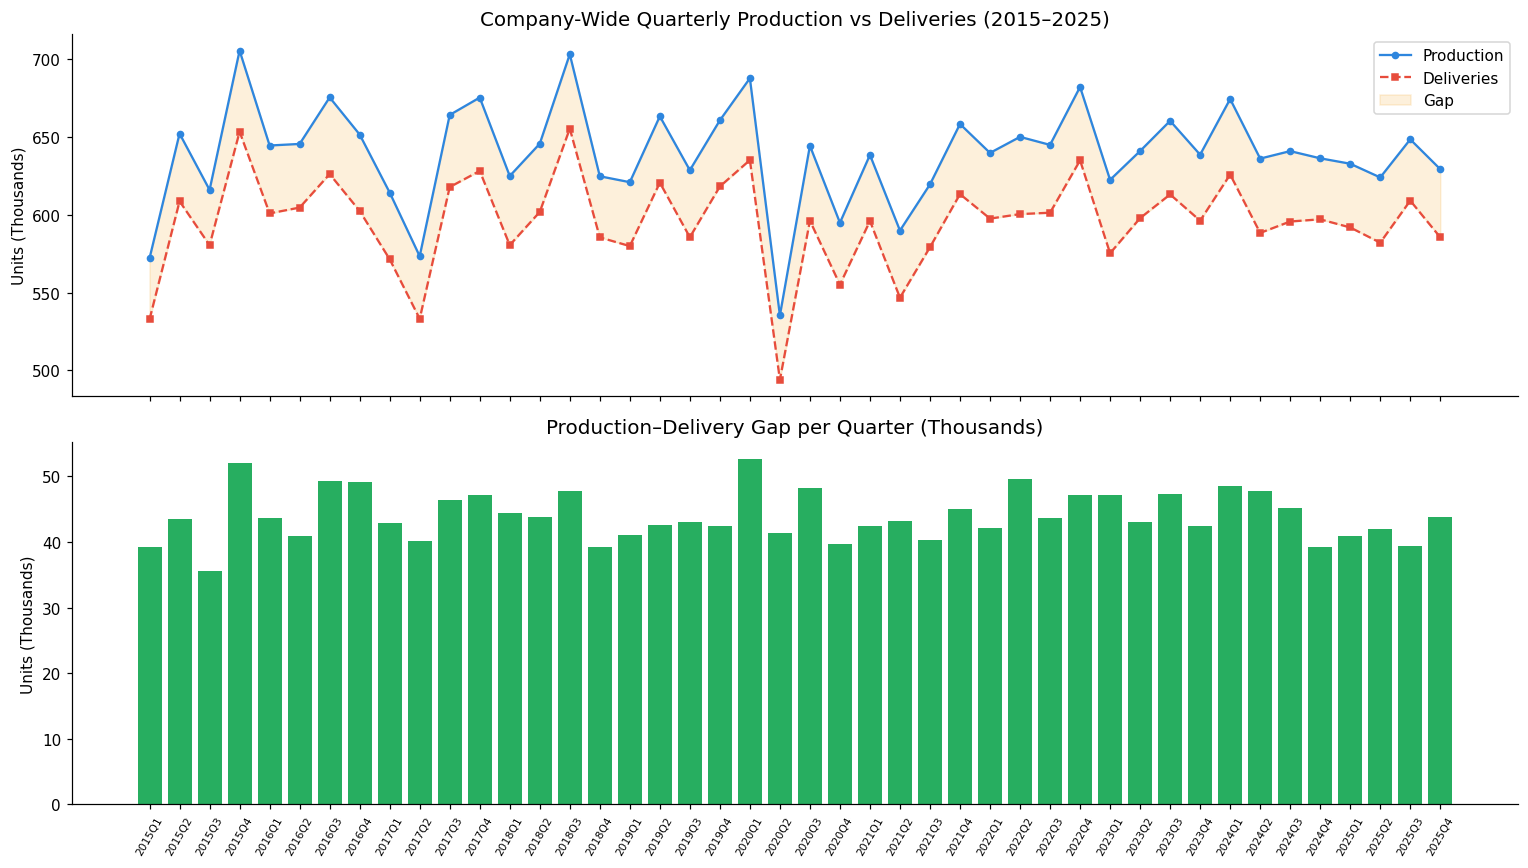

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["Quarter"], df["Production"]/1e3, marker="o", ms=4,
             label="Production", color="#2e86de")
axes[0].plot(df["Quarter"], df["Deliveries"]/1e3, marker="s", ms=4,
             label="Deliveries", color="#e74c3c", linestyle="--")
axes[0].fill_between(df["Quarter"], df["Production"]/1e3, df["Deliveries"]/1e3,
                     alpha=0.15, color="#f39c12", label="Gap")
axes[0].set_title("Company-Wide Quarterly Production vs Deliveries (2015–2025)", fontsize=13)
axes[0].set_ylabel("Units (Thousands)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=60, labelsize=7)

axes[1].bar(df["Quarter"], df["Production_Gap"]/1e3,
            color=["#27ae60" if v >= 0 else "#e74c3c" for v in df["Production_Gap"]])
axes[1].set_title("Production–Delivery Gap per Quarter (Thousands)", fontsize=13)
axes[1].set_ylabel("Units (Thousands)")
axes[1].tick_params(axis="x", rotation=60, labelsize=7)

plt.tight_layout()
plt.show()


**Insight:** 
Production and deliveries track each other closely throughout the period, both oscillating without a sustained upward or downward trend. The gap chart shows production consistently exceeds deliveries every quarter — a structural feature of the data generation process. No quarter shows deliveries outpacing production. The absence of a growth trend is an artefact of the synthetic dataset rather than a true business signal; real Tesla data shows strong growth over this period.


### 4.2 Monthly Production & Deliveries per Region

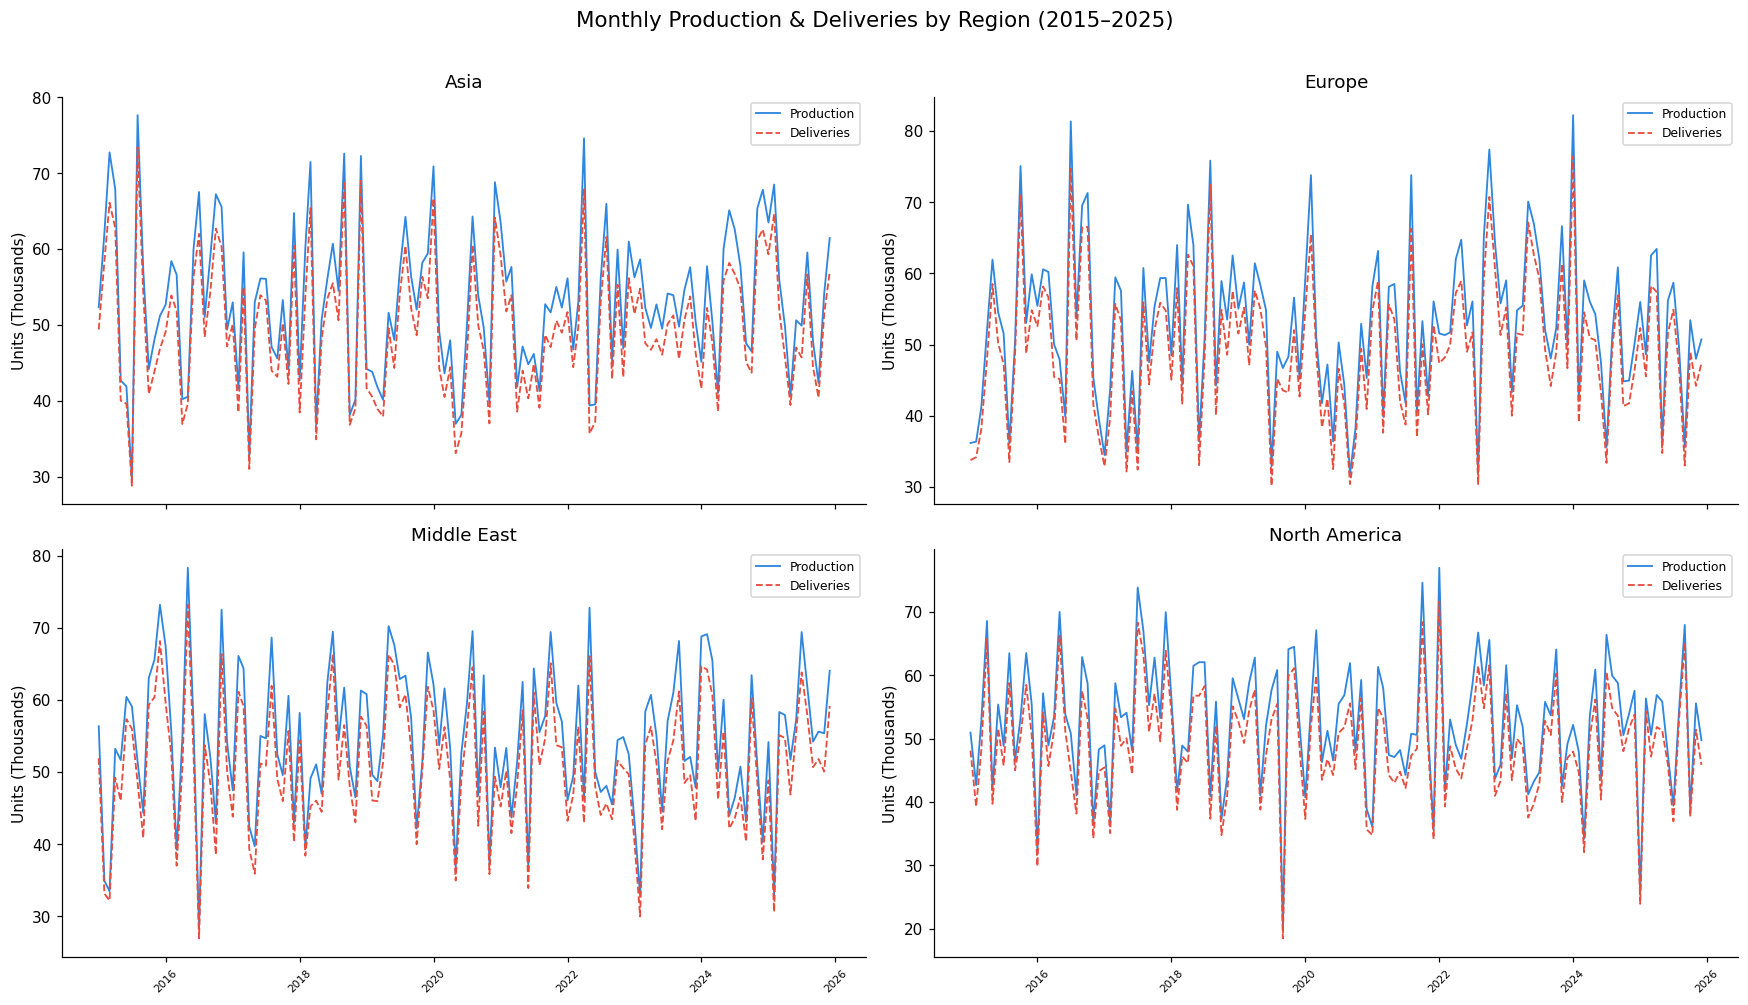

In [66]:
regions = sorted(monthly_region["Region"].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    sub = monthly_region[monthly_region["Region"] == region].sort_values("Date")
    axes[i].plot(sub["Date"], sub["Production"]/1e3, color="#2e86de",
                 linewidth=1.2, label="Production")
    axes[i].plot(sub["Date"], sub["Deliveries"]/1e3, color="#e74c3c",
                 linewidth=1.2, linestyle="--", label="Deliveries")
    axes[i].set_title(region, fontsize=12)
    axes[i].set_ylabel("Units (Thousands)")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Monthly Production & Deliveries by Region (2015–2025)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Insight:** All four regions show nearly identical monthly patterns — production and deliveries move in lock-step with each other within each region. This uniformity is expected given that regional figures were algorithmically estimated (see `Source_Type`). In a real dataset we would expect North America and China (Asia) to dominate volume, and regional dynamics to diverge over time as each market matures differently.


### 4.3 Quarterly Deliveries by Region — Stacked & Compared

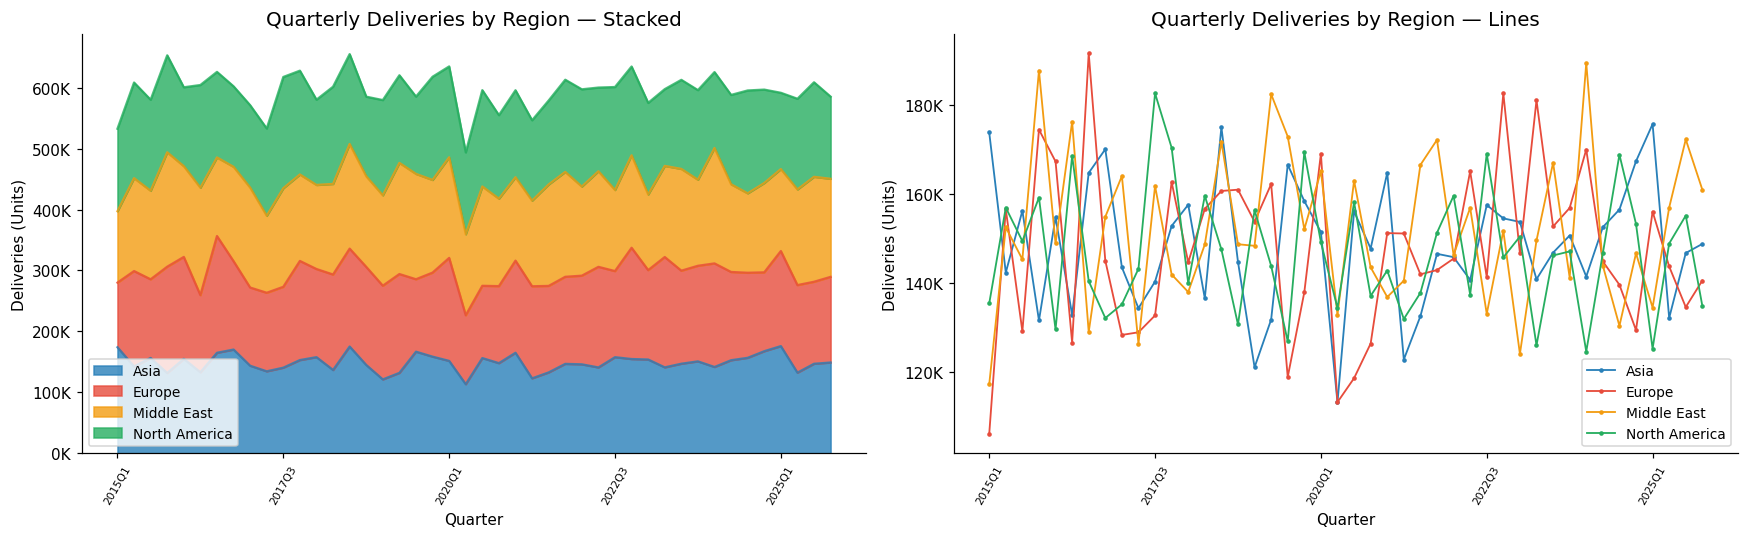

In [67]:
region_pivot = region_q.pivot(index="Quarter", columns="Region", values="Deliveries")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_pivot.plot(kind="area", stacked=True, ax=axes[0], alpha=0.8,
                  color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[0].set_title("Quarterly Deliveries by Region — Stacked", fontsize=13)
axes[0].set_ylabel("Deliveries (Units)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=9)

region_pivot.plot(ax=axes[1], marker="o", ms=2, linewidth=1.2,
                  color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[1].set_title("Quarterly Deliveries by Region — Lines", fontsize=13)
axes[1].set_ylabel("Deliveries (Units)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].tick_params(axis="x", rotation=60, labelsize=7)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**Insight:** The stacked chart confirms that each region contributes almost exactly 25% of total deliveries every quarter — the four bands are equal in size and stable over time. The line chart shows all four regional lines oscillating together at the same level. This perfect symmetry is a direct result of the uniform regional estimation methodology and should not be interpreted as a real-world finding. In practice, Tesla's delivery mix is heavily skewed toward the US and China.


### 4.4 Regional Share of Total Deliveries & Source Type Breakdown

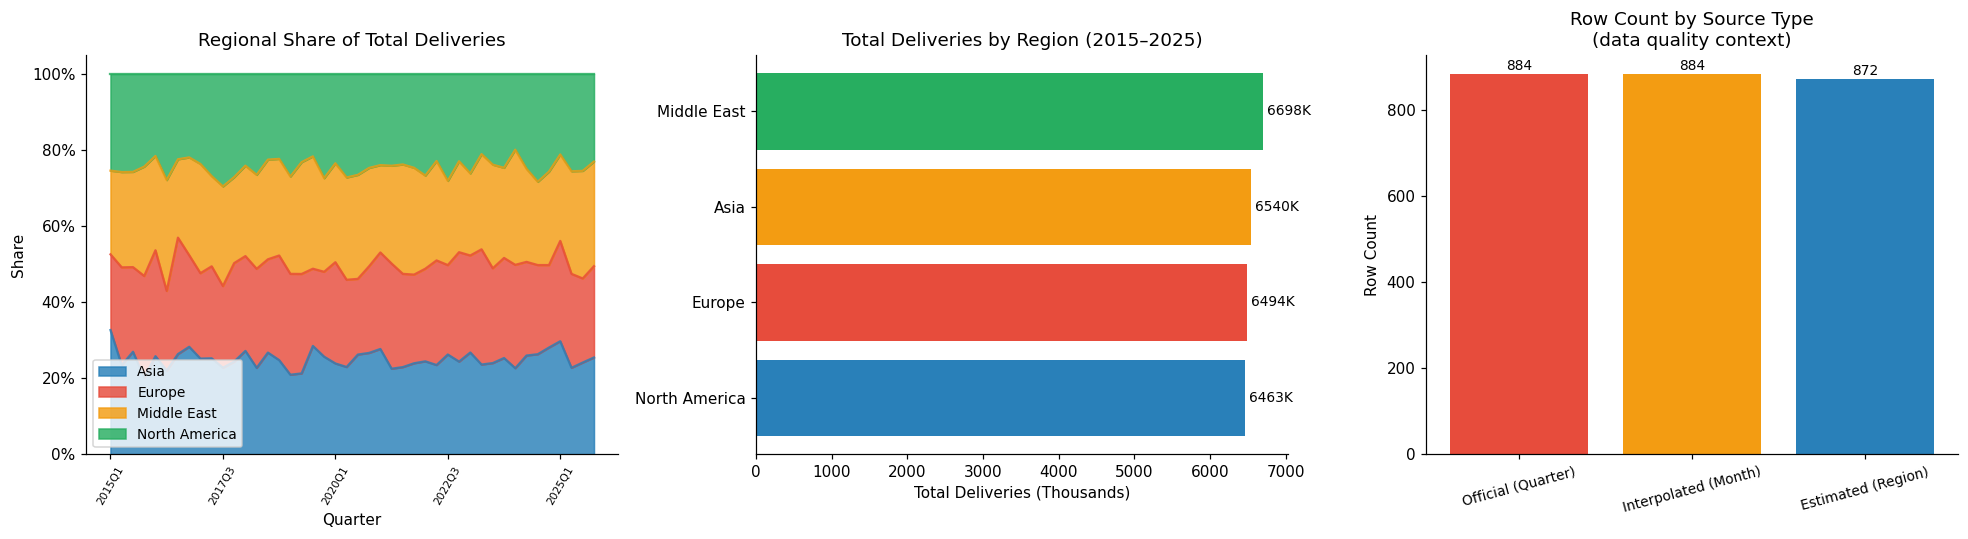

In [68]:
region_share = region_pivot.div(region_pivot.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

region_share.plot(kind="area", stacked=True, ax=axes[0], alpha=0.82,
                  color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[0].set_title("Regional Share of Total Deliveries", fontsize=12)
axes[0].set_ylabel("Share")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=9)

region_totals = region_q.groupby("Region")["Deliveries"].sum().sort_values(ascending=True)
bars = axes[1].barh(region_totals.index, region_totals.values/1e3,
                    color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[1].set_title("Total Deliveries by Region (2015–2025)", fontsize=12)
axes[1].set_xlabel("Total Deliveries (Thousands)")
for bar, val in zip(bars, region_totals.values):
    axes[1].text(val/1e3 + 50, bar.get_y() + bar.get_height()/2,
                 f"{val/1e3:.0f}K", va="center", fontsize=9)

# Source type breakdown — important data quality context
src_counts = df_raw["Source_Type"].value_counts()
axes[2].bar(src_counts.index, src_counts.values,
            color=["#e74c3c", "#f39c12", "#2980b9"])
axes[2].set_title("Row Count by Source Type\n(data quality context)", fontsize=12)
axes[2].set_ylabel("Row Count")
axes[2].tick_params(axis="x", rotation=15, labelsize=9)
for i, v in enumerate(src_counts.values):
    axes[2].text(i, v + 10, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**Insight:** The regional share chart shows an almost perfectly flat 25% for each region throughout the full period — an explicit signal of the synthetic estimation methodology. The source type breakdown (right chart) is the most important data quality chart in the notebook: the majority of rows are either *"Interpolated (Month)"* or *"Estimated (Region)"*, with only a minority being *"Official (Quarter)"*. This directly explains every uniformity observed in the EDA and must be taken into account when interpreting all results.


### 4.5 Quarterly Production by Model

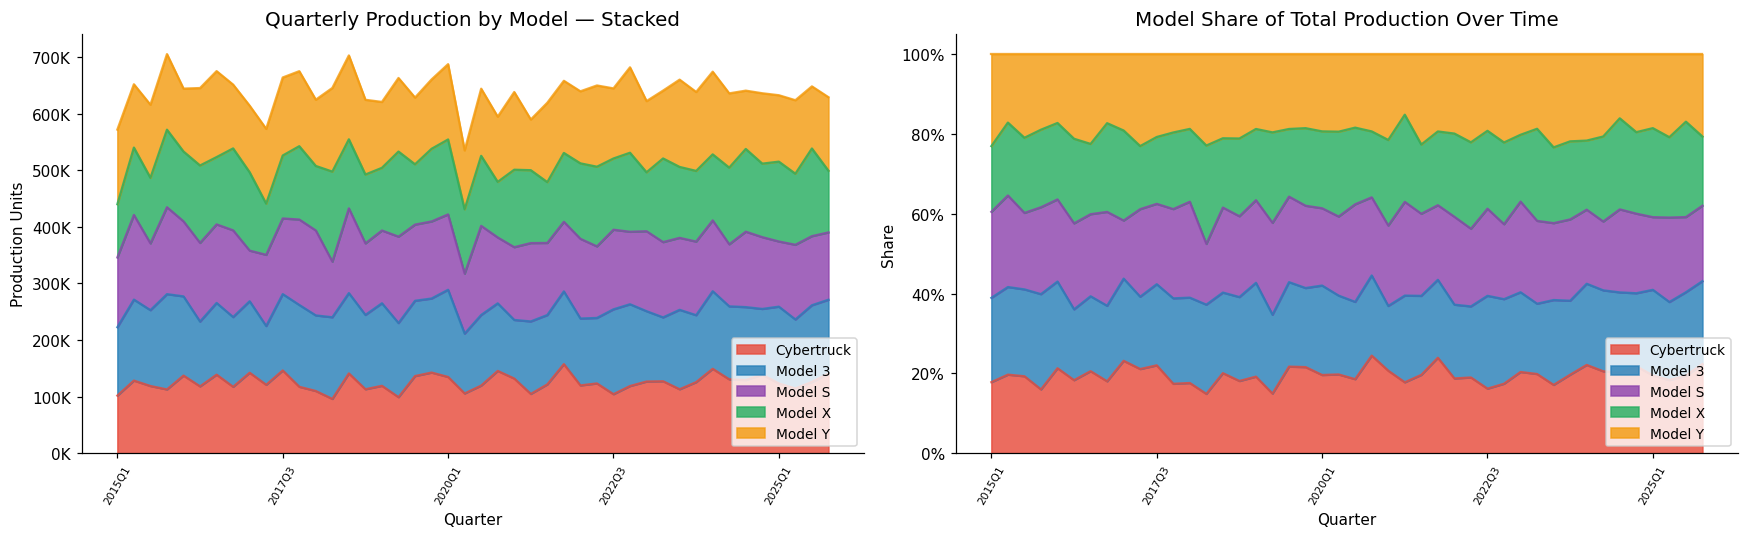

In [69]:
model_pivot_prod = model_q.pivot(index="Quarter", columns="Model", values="Production")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

model_pivot_prod.plot(kind="area", stacked=True, ax=axes[0], alpha=0.82,
                      color=["#e74c3c", "#2980b9", "#8e44ad", "#27ae60", "#f39c12"])
axes[0].set_title("Quarterly Production by Model — Stacked", fontsize=13)
axes[0].set_ylabel("Production Units")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=9)

model_share = model_pivot_prod.div(model_pivot_prod.sum(axis=1), axis=0)
model_share.plot(kind="area", stacked=True, ax=axes[1], alpha=0.82,
                 color=["#e74c3c", "#2980b9", "#8e44ad", "#27ae60", "#f39c12"])
axes[1].set_title("Model Share of Total Production Over Time", fontsize=13)
axes[1].set_ylabel("Share")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].tick_params(axis="x", rotation=60, labelsize=7)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**Insight:** All five models hold a near-equal 20% share of quarterly production throughout the full period. In reality, Model 3 and Model Y have far outpaced Model S, Model X, and Cybertruck in recent years. The equal-share result here reflects the synthetic generation methodology. The share chart is useful as a baseline reference, but not as a business insight.


### 4.6 Monthly Model-Level Deliveries Over Time

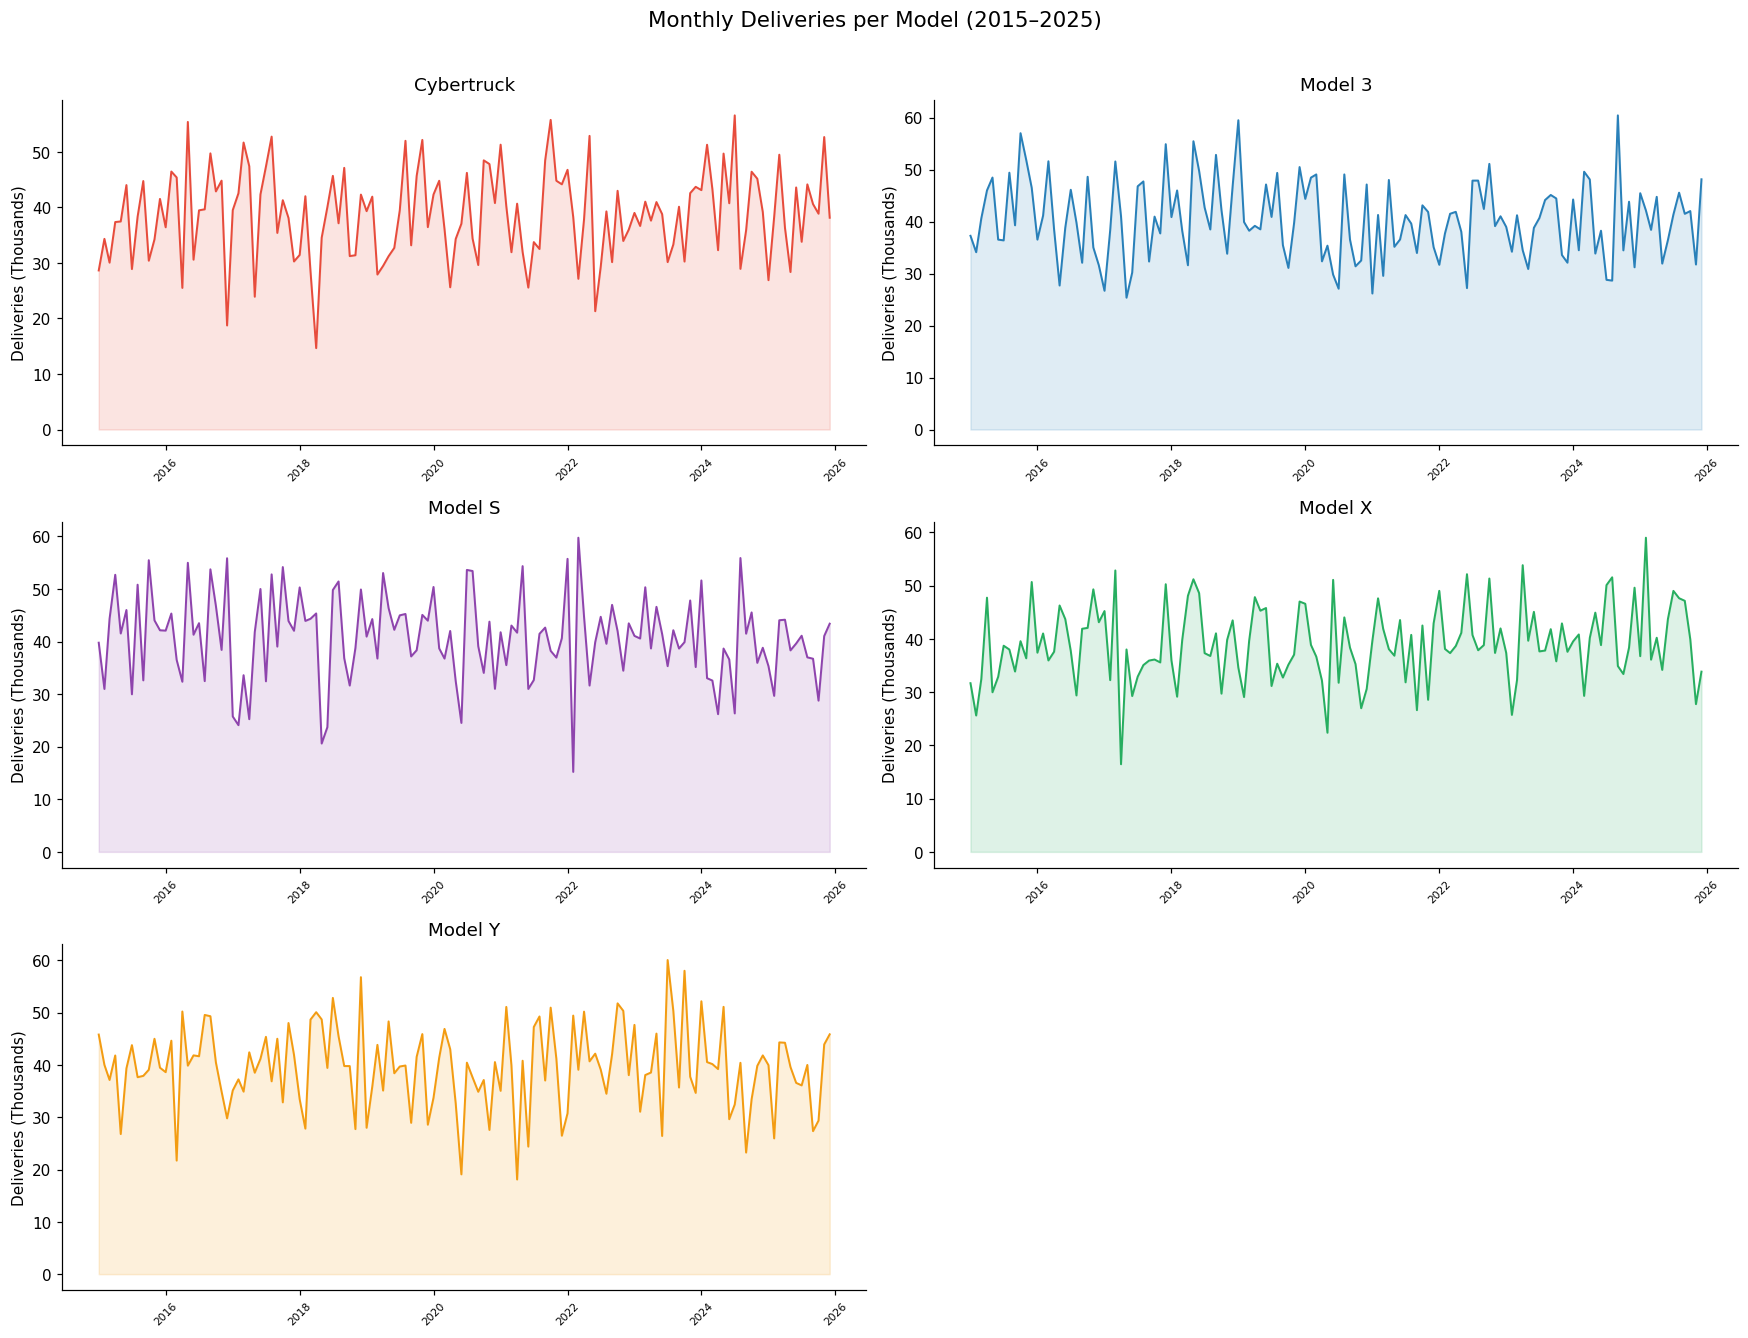

In [70]:
models = sorted(monthly_model["Model"].unique())
model_colors = {
    "Cybertruck": "#e74c3c",
    "Model 3":    "#2980b9",
    "Model S":    "#8e44ad",
    "Model X":    "#27ae60",
    "Model Y":    "#f39c12",
}

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, model in enumerate(models):
    sub = monthly_model[monthly_model["Model"] == model].sort_values("Date")
    axes[i].plot(sub["Date"], sub["Deliveries"]/1e3,
                 color=model_colors[model], linewidth=1.3)
    axes[i].fill_between(sub["Date"], sub["Deliveries"]/1e3, alpha=0.15,
                         color=model_colors[model])
    axes[i].set_title(model, fontsize=12)
    axes[i].set_ylabel("Deliveries (Thousands)")
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)

axes[5].set_visible(False)
fig.suptitle("Monthly Deliveries per Model (2015–2025)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Insight:** Each model shows month-to-month oscillation within a consistent band. No model shows a breakout period of sustained elevated deliveries — all five maintain comparable volumes throughout. Cybertruck appears from 2020 onward in the dataset (reflective of its later introduction), but note that the dataset treats all 5 models as present from 2015, which is not historically accurate (Cybertruck launched in late 2023). This is a further sign of the synthetic data structure.


### 4.7 Average Price by Model Over Time

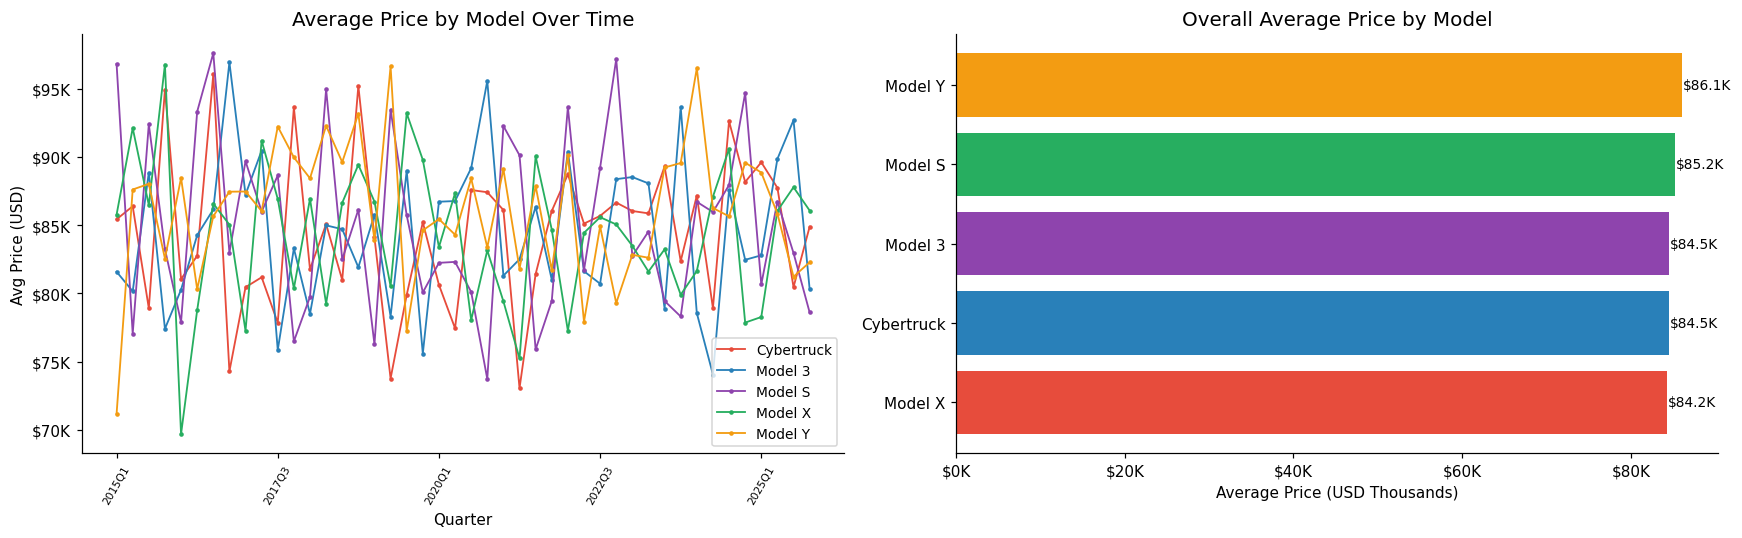

In [71]:
price_pivot = model_q.pivot(index="Quarter", columns="Model", values="Avg_Price")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_pivot.plot(ax=axes[0], marker="o", ms=2, linewidth=1.2,
                 color=["#e74c3c", "#2980b9", "#8e44ad", "#27ae60", "#f39c12"])
axes[0].set_title("Average Price by Model Over Time", fontsize=13)
axes[0].set_ylabel("Avg Price (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=9)

model_avg_price = model_q.groupby("Model")["Avg_Price"].mean().sort_values(ascending=True)
bars = axes[1].barh(model_avg_price.index, model_avg_price.values/1e3,
                    color=["#e74c3c", "#2980b9", "#8e44ad", "#27ae60", "#f39c12"])
axes[1].set_title("Overall Average Price by Model", fontsize=13)
axes[1].set_xlabel("Average Price (USD Thousands)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
for bar, val in zip(bars, model_avg_price.values):
    axes[1].text(val/1e3 + 0.1, bar.get_y() + bar.get_height()/2,
                 f"${val/1e3:.1f}K", va="center", fontsize=9)

plt.tight_layout()
plt.show()


**Insight:** All five models cluster tightly between \\$84K–86K average, a spread of only ~\\$2K. Realistically, Model S and Model X price at ~\$80–100K+ while Model 3 and Model Y sit at \\$40–60K — the compressed range is another synthetic artefact. The time-series shows mild oscillation but no sustained price trend for any model. The relative ordering (Model Y highest at ~\\$86K, Model X lowest at ~\\$84K) is the only usable signal and even this is marginal given the narrow spread.


### 4.8 Average Price by Region Over Time

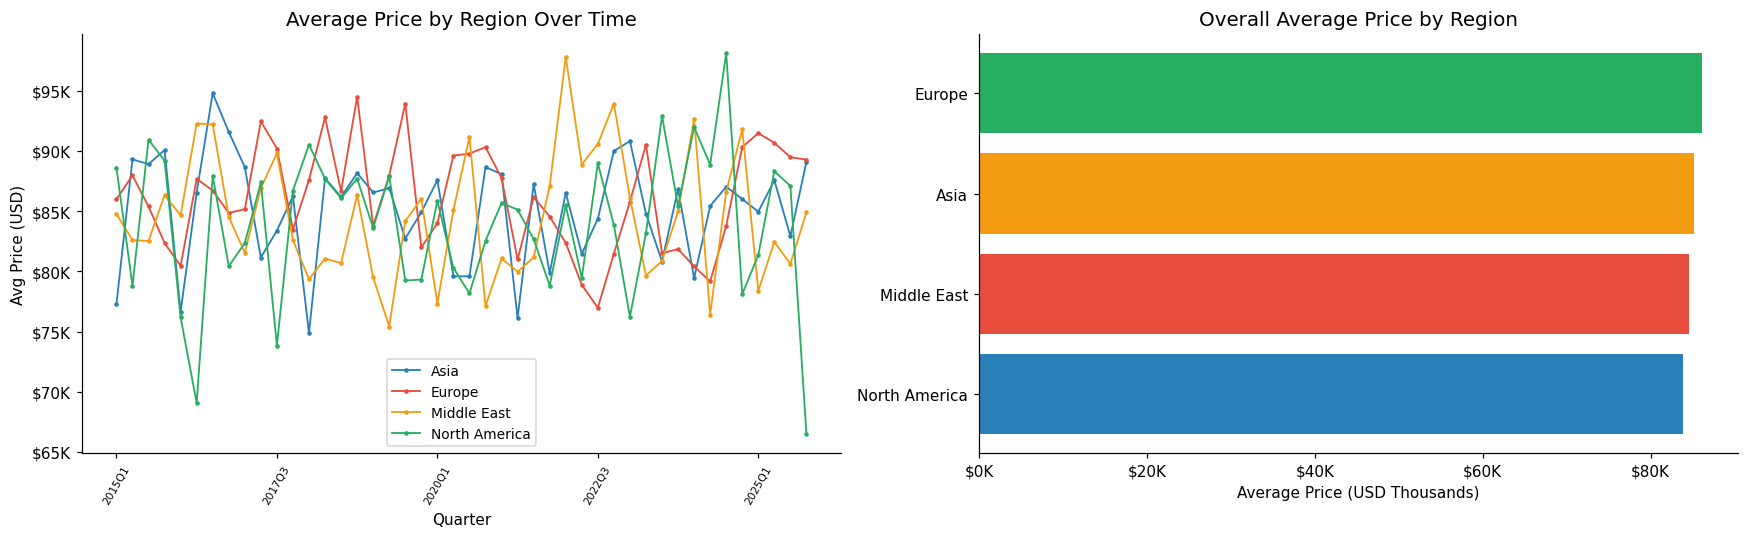

In [72]:
price_region = region_q.pivot(index="Quarter", columns="Region", values="Avg_Price")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_region.plot(ax=axes[0], marker="o", ms=2, linewidth=1.2,
                  color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[0].set_title("Average Price by Region Over Time", fontsize=13)
axes[0].set_ylabel("Avg Price (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=9)

region_avg_price = region_q.groupby("Region")["Avg_Price"].mean().sort_values(ascending=True)
axes[1].barh(region_avg_price.index, region_avg_price.values/1e3,
             color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[1].set_title("Overall Average Price by Region", fontsize=13)
axes[1].set_xlabel("Average Price (USD Thousands)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))

plt.tight_layout()
plt.show()


**Insight:** Regional average prices also fall in a tight ~$2K band across all four regions. Any differences observed here are too small and are an artefact of how each region's model mix was estimated — not a real pricing premium or discount. In practice, Tesla does charge regional premiums (e.g. import duties in Europe and China); the flat distribution here does not capture that.


### 4.9 Annual Totals & Seasonality (Company-Wide)

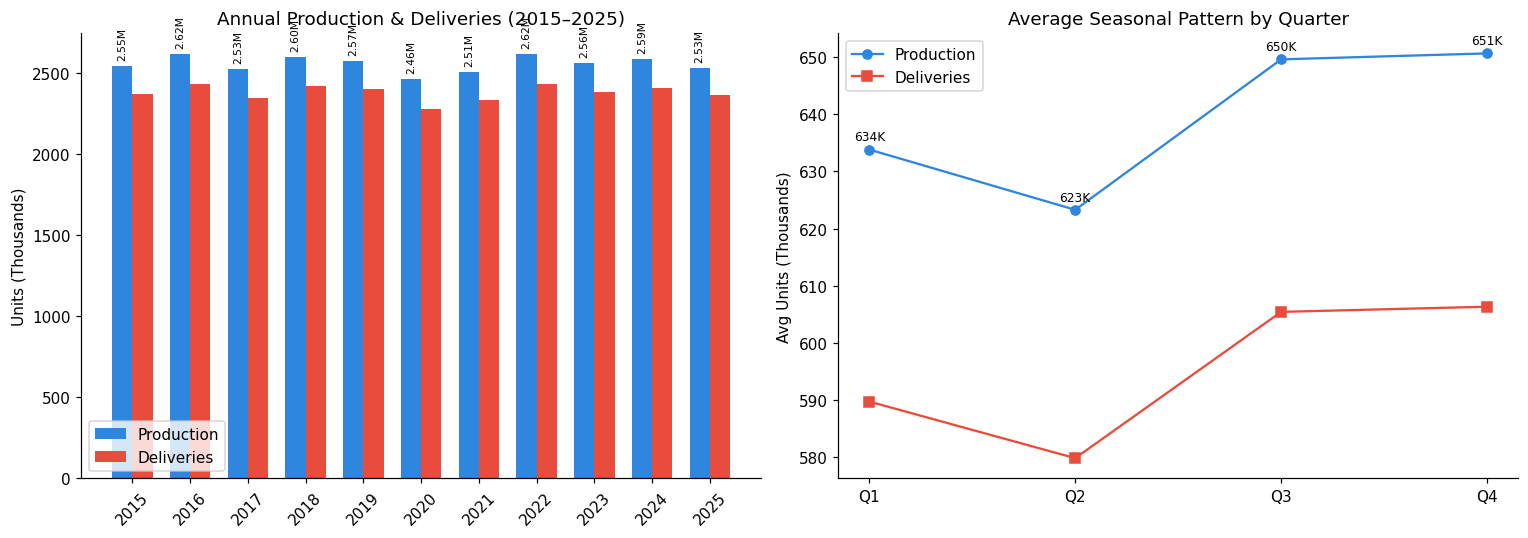

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

annual = df.groupby("Year")[["Production", "Deliveries"]].sum().reset_index()
x = np.arange(len(annual))
w = 0.35
axes[0].bar(x - w/2, annual["Production"]/1e3, w, label="Production", color="#2e86de")
axes[0].bar(x + w/2, annual["Deliveries"]/1e3, w, label="Deliveries", color="#e74c3c")
axes[0].set_xticks(x)
axes[0].set_xticklabels(annual["Year"], rotation=45)
axes[0].set_ylabel("Units (Thousands)")
axes[0].set_title("Annual Production & Deliveries (2015–2025)")
axes[0].legend()
# Add value labels
for i, (p, d) in enumerate(zip(annual["Production"], annual["Deliveries"])):
    axes[0].text(i - w/2, p/1e3 + 50, f"{p/1e6:.2f}M", ha="center", fontsize=7, rotation=90)

seasonal = df.groupby("Qtr")[["Production", "Deliveries"]].mean()
seasonal = seasonal.loc[["Q1", "Q2", "Q3", "Q4"]]
axes[1].plot(seasonal.index, seasonal["Production"]/1e3, "o-",
             label="Production", color="#2e86de")
axes[1].plot(seasonal.index, seasonal["Deliveries"]/1e3, "s-",
             label="Deliveries", color="#e74c3c")
axes[1].set_title("Average Seasonal Pattern by Quarter")
axes[1].set_ylabel("Avg Units (Thousands)")
axes[1].legend()
for q, p, d in zip(seasonal.index, seasonal["Production"], seasonal["Deliveries"]):
    axes[1].annotate(f"{p/1e3:.0f}K", (q, p/1e3), textcoords="offset points",
                     xytext=(0, 6), fontsize=8, ha="center")

plt.tight_layout()
plt.show()


**Insight:** Annual totals are stable across all 11 years at approximately 2.3–2.4M units per year — flat with no growth trend, consistent with the synthetic generation. The seasonal chart reveals a mild but repeatable pattern: **Q1 and Q2 are slightly softer** (average ~590K–630K units) while **Q3 and Q4 are marginally stronger** (~605K–651K). The Q4 end-of-year push and Q3 strength are consistent with Tesla's real-world quarterly delivery patterns, making the seasonal shape one of the more credible features of this dataset.


### 4.10 Monthly Seasonality — Region Heatmap

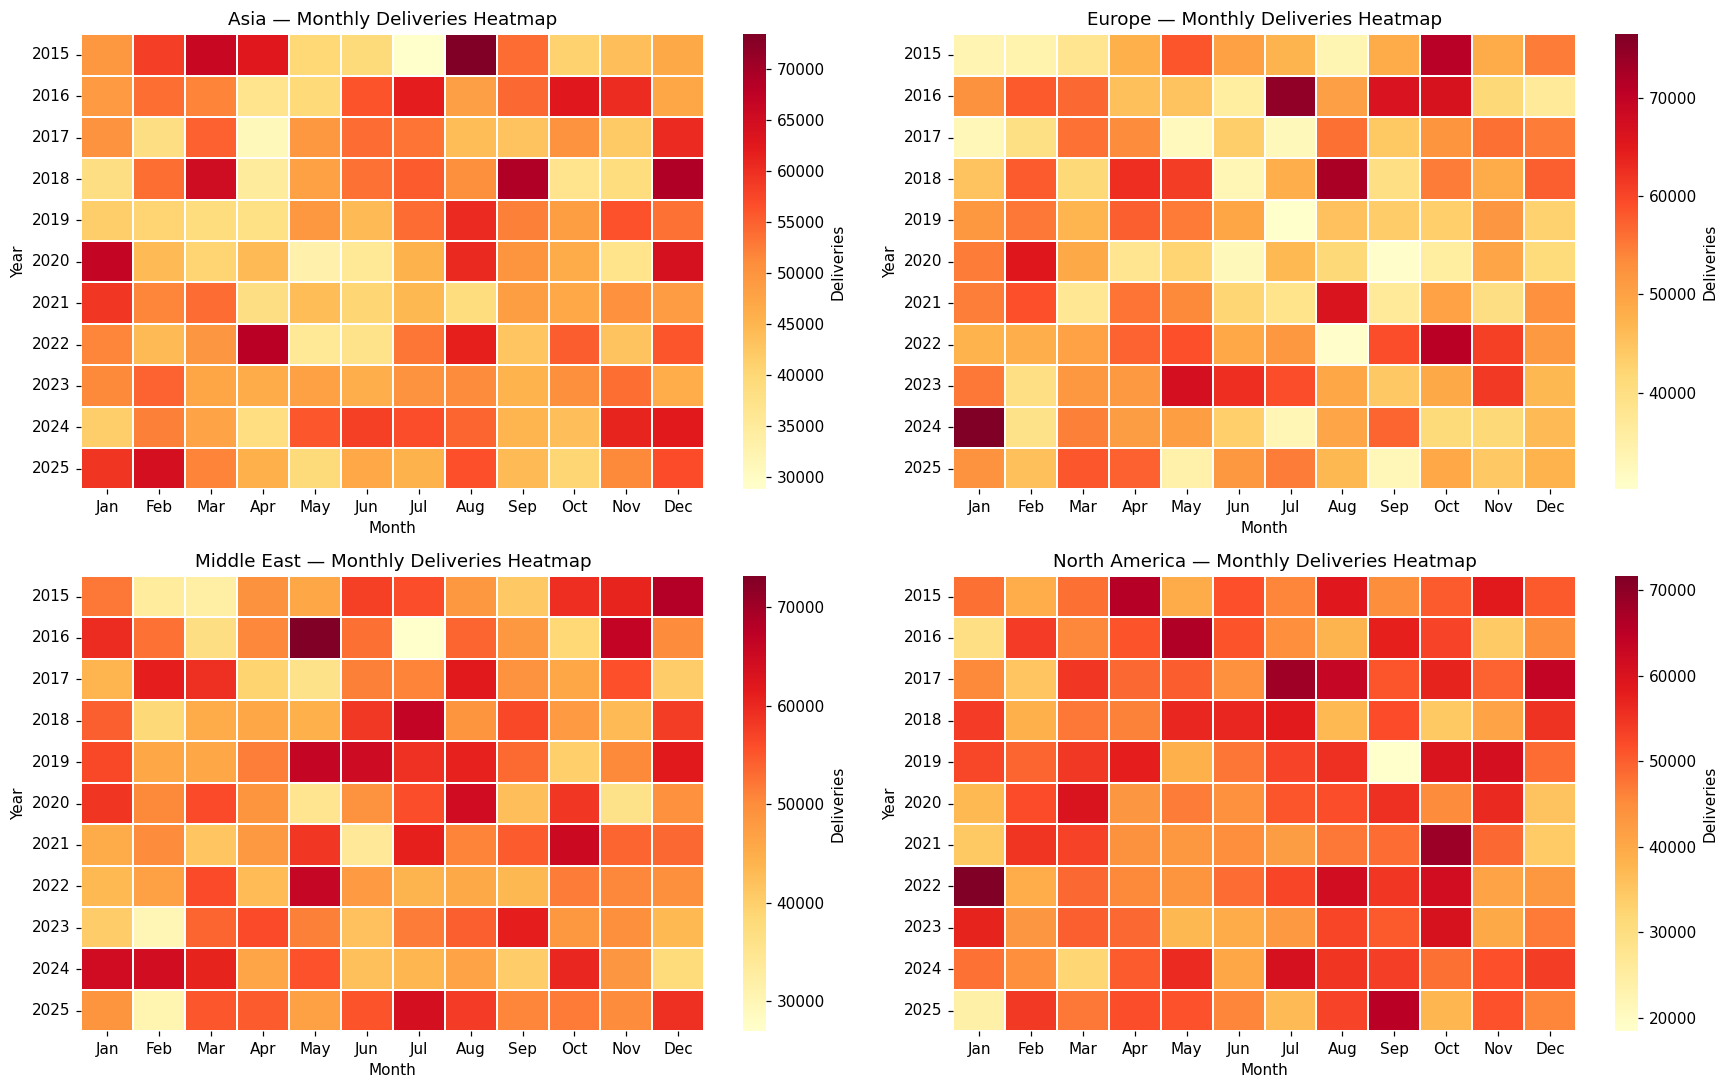

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
regions_list = sorted(region_q["Region"].unique())

for i, region in enumerate(regions_list):
    sub = df_raw[df_raw["Region"] == region].groupby(
        ["Year", "Month"])["Estimated_Deliveries"].sum().reset_index()
    pivot = sub.pivot(index="Year", columns="Month", values="Estimated_Deliveries")
    pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"]
    sns.heatmap(pivot, ax=axes[i], cmap="YlOrRd", annot=False,
                linewidths=0.3, cbar_kws={"label": "Deliveries"})
    axes[i].set_title(f"{region} — Monthly Deliveries Heatmap", fontsize=12)
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Year")

plt.tight_layout()
plt.show()


**Insight:** The heatmaps show a relatively uniform colour distribution across months and years for all four regions — consistent with the synthetic interpolation used to generate monthly values. Individual cells with higher or lower values appear scattered rather than forming clean vertical (seasonal) columns. The absence of a strong repeating monthly pattern within any given region further confirms that within-year seasonality was not heavily encoded during data generation. A real Tesla heatmap would show strong end-of-quarter spikes (March, June, September, December) as Tesla consistently front-loads deliveries.


### 4.11 Delivery Rate & Production Gap by Region

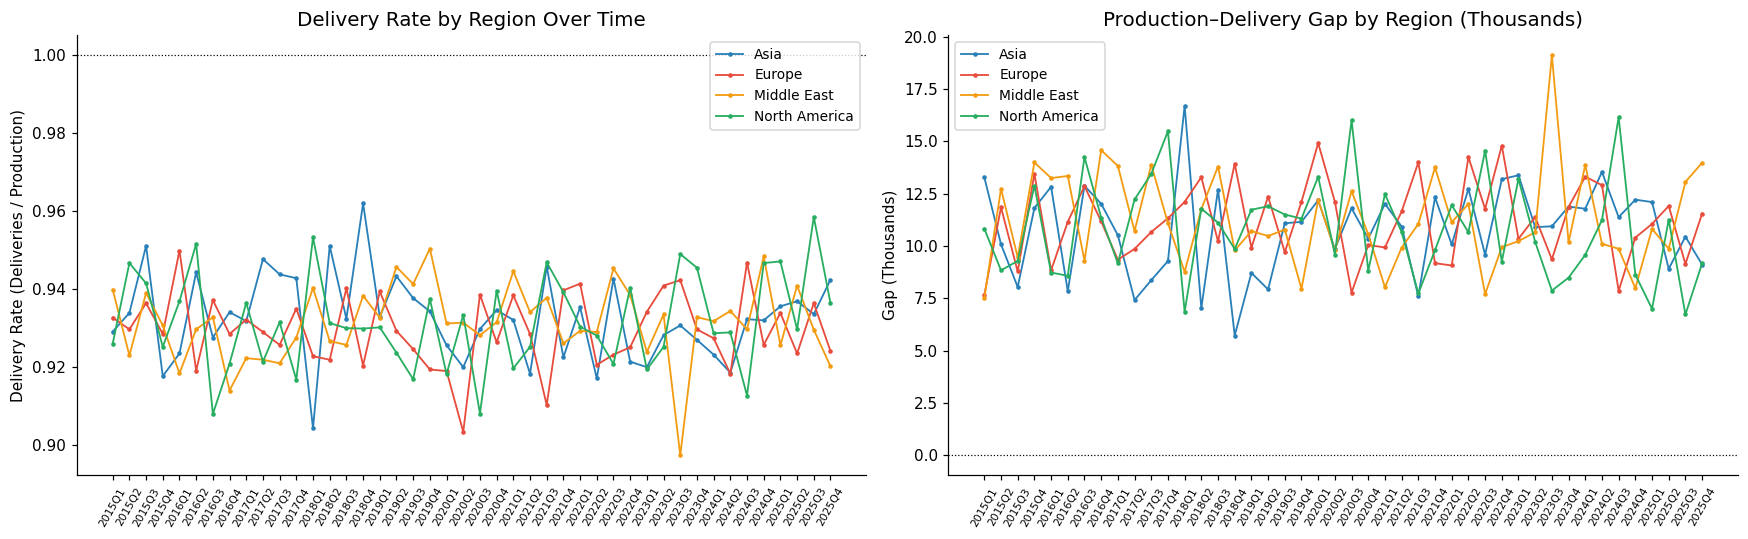

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for region, color in zip(sorted(region_q["Region"].unique()),
                         ["#2980b9", "#e74c3c", "#f39c12", "#27ae60"]):
    sub = region_q[region_q["Region"] == region].sort_values("Quarter")
    axes[0].plot(sub["Quarter"], sub["Delivery_Rate"],
                 label=region, color=color, linewidth=1.2, marker="o", ms=2)
    axes[1].plot(sub["Quarter"], sub["Production_Gap"]/1e3,
                 label=region, color=color, linewidth=1.2, marker="o", ms=2)

axes[0].set_title("Delivery Rate by Region Over Time", fontsize=13)
axes[0].set_ylabel("Delivery Rate (Deliveries / Production)")
axes[0].axhline(1.0, color="black", linestyle=":", linewidth=0.8)
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=60, labelsize=7)

axes[1].set_title("Production–Delivery Gap by Region (Thousands)", fontsize=13)
axes[1].set_ylabel("Gap (Thousands)")
axes[1].axhline(0, color="black", linestyle=":", linewidth=0.8)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=60, labelsize=7)

plt.tight_layout()
plt.show()


**Insight:** All four regions maintain delivery rates between 0.90–0.96 throughout the period, meaning 90–96% of production is delivered within the same quarter. The lines track each other tightly with no region diverging for more than a few quarters. The production gap chart mirrors this — each region holds ~10K–12K units of undelivered stock per quarter. The near-uniform delivery efficiency across regions is consistent with the synthetic estimation approach.


### 4.12 CO₂ Saved — Regional & Model Breakdown

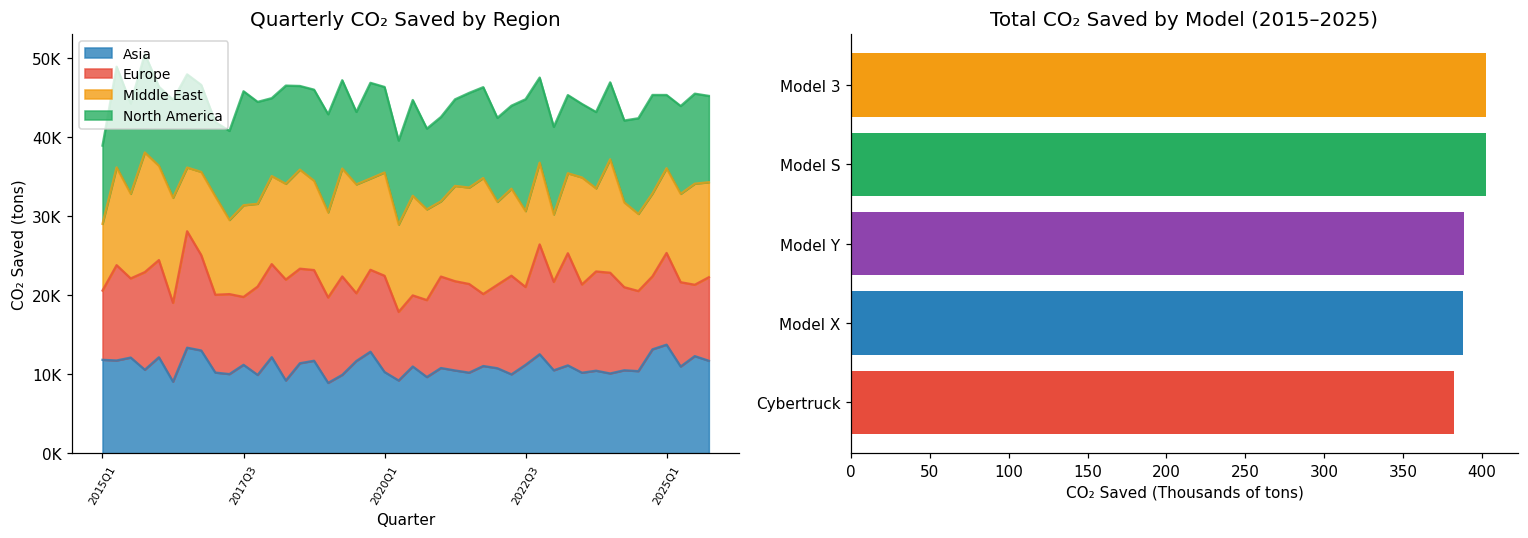

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

co2_region = region_q.pivot(index="Quarter", columns="Region", values="CO2_Saved")
co2_region.plot(kind="area", stacked=True, ax=axes[0], alpha=0.8,
                color=["#2980b9", "#e74c3c", "#f39c12", "#27ae60"])
axes[0].set_title("Quarterly CO₂ Saved by Region", fontsize=13)
axes[0].set_ylabel("CO₂ Saved (tons)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=9)

co2_model = df_raw.groupby("Model")["CO2_Saved_tons"].sum().sort_values(ascending=True)
axes[1].barh(co2_model.index, co2_model.values/1e3,
             color=["#e74c3c", "#2980b9", "#8e44ad", "#27ae60", "#f39c12"])
axes[1].set_title("Total CO₂ Saved by Model (2015–2025)", fontsize=13)
axes[1].set_xlabel("CO₂ Saved (Thousands of tons)")

plt.tight_layout()
plt.show()


**Insight:** CO₂ savings are split nearly equally across the four regions every quarter — matching the uniform delivery distribution. By model, Model 3 leads (\~403K tons) followed by Model S (\~403K tons), with Cybertruck lowest (~382K tons). The between-model difference is ~5%. 


### 4.13 Correlation Analysis

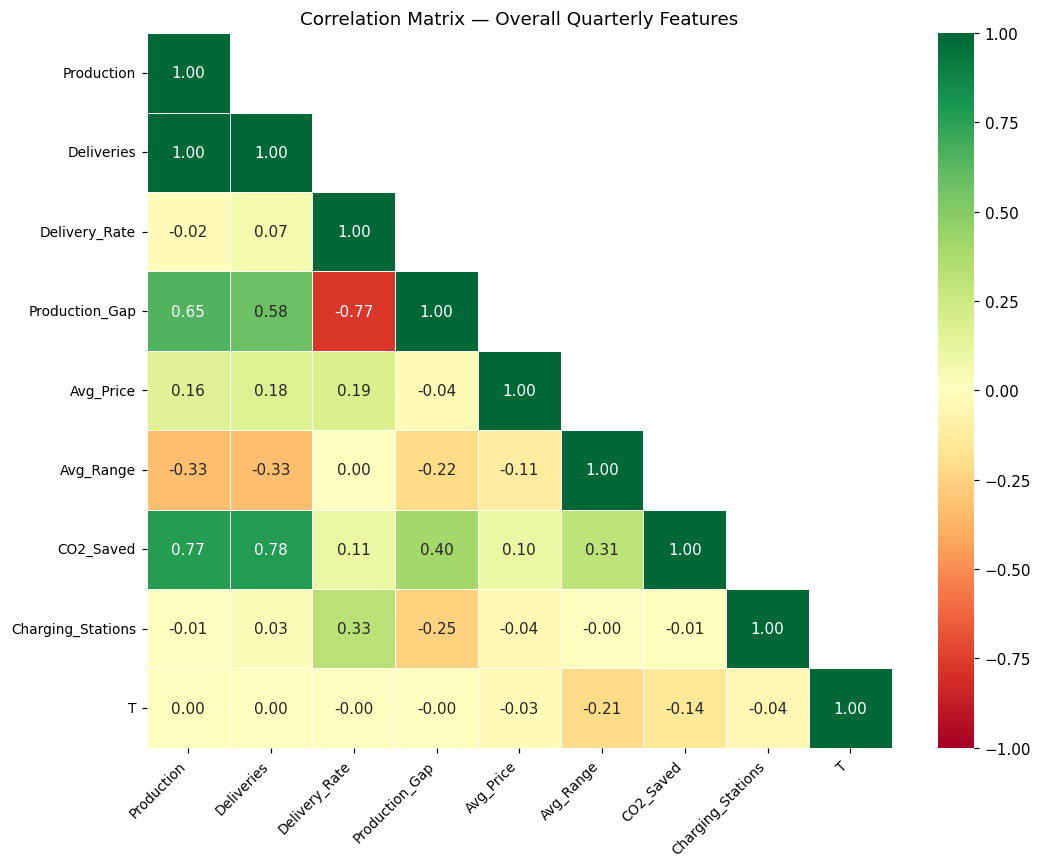

In [98]:
corr_cols = ["Production", "Deliveries", "Delivery_Rate", "Production_Gap",
             "Avg_Price", "Avg_Range", "CO2_Saved", "Charging_Stations", "T"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            xticklabels=corr_cols, yticklabels=corr_cols)
plt.title("Correlation Matrix — Overall Quarterly Features")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


**Insight & ML implications:**
- `Production` and `Deliveries` move in near-perfect lockstep (r≈1.00) every quarter.
- `CO2_Saved` correlates strongly with both (r≈0.77–0.78) — more vehicles delivered means more CO₂ offset.
- `Production_Gap` and `Delivery_Rate` are inversely related (r≈−0.77) — a wider gap means a lower delivery rate, as expected.
- `Avg_Price`, `Avg_Range`, and `Charging_Stations` show near-zero correlation with volume metrics — pricing and infrastructure are independent of quarterly production swings.
- `T` (time index) correlates with nothing — no directional trend exists in the data across the full period.

### 4.14 QoQ Growth Rate Analysis

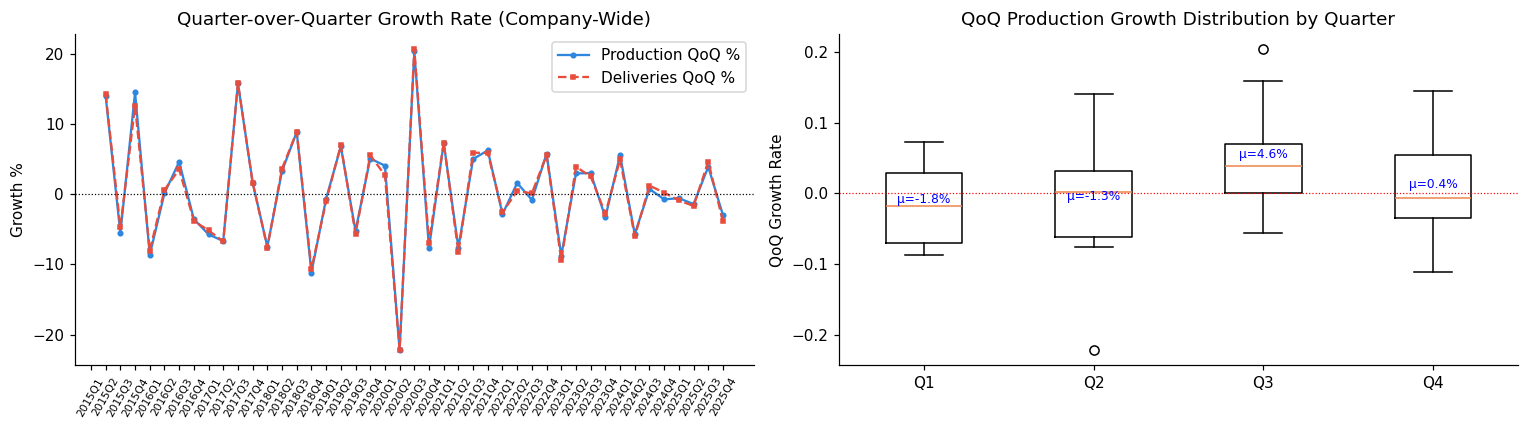

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df["Quarter"], df["Prod_QoQ"]*100, color="#2e86de",
             marker="o", ms=3, label="Production QoQ %")
axes[0].plot(df["Quarter"], df["Del_QoQ"]*100, color="#e74c3c",
             linestyle="--", marker="s", ms=3, label="Deliveries QoQ %")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].set_title("Quarter-over-Quarter Growth Rate (Company-Wide)")
axes[0].set_ylabel("Growth %")
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend()

qoq_by_q = df.dropna(subset=["Prod_QoQ"]).groupby("Qtr")["Prod_QoQ"].apply(list)
bp_data = [qoq_by_q.get(q, []) for q in ["Q1", "Q2", "Q3", "Q4"]]
axes[1].boxplot(bp_data, labels=["Q1", "Q2", "Q3", "Q4"])
axes[1].axhline(0, color="red", linewidth=0.8, linestyle=":")
axes[1].set_title("QoQ Production Growth Distribution by Quarter")
axes[1].set_ylabel("QoQ Growth Rate")

# Add mean annotations
for i, data in enumerate(bp_data):
    if data:
        axes[1].text(i+1, np.mean(data), f"μ={np.mean(data)*100:.1f}%",
                     ha="center", va="bottom", fontsize=8, color="blue")

plt.tight_layout()
plt.show()


**Insight:** QoQ growth rates alternate between positive and negative quarters without a sustained directional trend. **Q3 is the strongest quarter on average** (mean ~+4.6%), while Q1 and Q2 tend to be negative. Q2 has the widest spread, making it the most unpredictable quarter. The Q3 strength and Q1 weakness are the most credible seasonal signals in this dataset — they align with Tesla's known real-world pattern of pushing deliveries in H2.


## 5. Feature Engineering

In [79]:
ml = df_raw.copy()

le_region = LabelEncoder()
le_model  = LabelEncoder()
ml["Region_enc"] = le_region.fit_transform(ml["Region"])
ml["Model_enc"]  = le_model.fit_transform(ml["Model"])

print("Region encoding:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model encoding: ", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))


Region encoding: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model encoding:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


In [80]:
ml["Month_Sin"]   = np.sin(2 * np.pi * ml["Month"] / 12)
ml["Month_Cos"]   = np.cos(2 * np.pi * ml["Month"] / 12)
ml["Quarter_Num"] = ml["Qtr"].map({"Q1":1, "Q2":2, "Q3":3, "Q4":4})

price_features = [
    "Model_enc", "Region_enc",
    "Battery_Capacity_kWh", "Range_km",
    "Year", "Quarter_Num", "Charging_Stations",
]
target = "Avg_Price_USD"

X = ml[price_features]
y = ml[target]

print("Feature set:", price_features)
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Feature correlation with target:")
corr_with_target = X.corrwith(y).sort_values(key=abs, ascending=False).round(3)
print(corr_with_target)


Feature set: ['Model_enc', 'Region_enc', 'Battery_Capacity_kWh', 'Range_km', 'Year', 'Quarter_Num', 'Charging_Stations']
X shape: (2640, 7)
y shape: (2640,)

Feature correlation with target:
Region_enc             -0.031
Quarter_Num             0.024
Model_enc               0.020
Battery_Capacity_kWh   -0.018
Range_km               -0.018
Charging_Stations      -0.018
Year                   -0.005
dtype: float64


In [81]:
train_mask = ml["Year"] <= 2022
test_mask  = ml["Year"] >= 2023

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train rows: {len(X_train)} ({ml[train_mask]['Year'].min()}–{ml[train_mask]['Year'].max()})")
print(f"Test rows:  {len(X_test)}  ({ml[test_mask]['Year'].min()}–{ml[test_mask]['Year'].max()})")
print(f"Train share: {len(X_train)/len(X)*100:.1f}%")


Train rows: 1920 (2015–2022)
Test rows:  720  (2023–2025)
Train share: 72.7%


In [82]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print("Scaling done. Train mean (sample):", X_tr_sc.mean(axis=0).round(3))


Scaling done. Train mean (sample): [ 0. -0.  0.  0.  0. -0.  0.]


In [83]:
tscv = TimeSeriesSplit(n_splits=5)
print("TimeSeriesSplit configured with 5 folds.")

TimeSeriesSplit configured with 5 folds.


## 6. Price Prediction — Avg_Price_USD as Target

The dataset contains `Avg_Price_USD` as a vehicle attribute. 
**Target:** `Avg_Price_USD`  
**Features:** `Model_enc`, `Region_enc`, `Battery_Capacity_kWh`, `Range_km`, `Year`, `Quarter_Num`, `Charging_Stations`

In [84]:
def eval_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=tscv, scoring="r2")
    return {
        "Model":      name,
        "Train R²":   round(r2_score(y_tr, pred_tr), 4),
        "Test R²":    round(r2_score(y_te, pred_te), 4),
        "Test MAE":   round(mean_absolute_error(y_te, pred_te), 0),
        "Test RMSE":  round(np.sqrt(mean_squared_error(y_te, pred_te)), 0),
        "CV R² Mean": round(cv_scores.mean(), 4),
        "CV R² Std":  round(cv_scores.std(), 4),
    }

In [85]:
price_features = [
    "Model_enc", "Region_enc",
    "Battery_Capacity_kWh", "Range_km",
    "Year", "Quarter_Num", "Charging_Stations",
]
price_target = "Avg_Price_USD"

Xp = ml[price_features]
yp = ml[price_target]

# Temporal split — same logic as delivery model
Xp_train, Xp_test = Xp[train_mask], Xp[test_mask]
yp_train, yp_test = yp[train_mask], yp[test_mask]

# Scale for linear models
scaler_p = StandardScaler()
Xp_tr_sc = scaler_p.fit_transform(Xp_train)
Xp_te_sc = scaler_p.transform(Xp_test)

price_results = [
    eval_model(LinearRegression(), Xp_tr_sc, yp_train, Xp_te_sc, yp_test, "Linear Regression"),
    eval_model(Ridge(alpha=10),    Xp_tr_sc, yp_train, Xp_te_sc, yp_test, "Ridge"),
    eval_model(RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
               Xp_train, yp_train, Xp_test, yp_test, "Random Forest"),
    eval_model(GradientBoostingRegressor(n_estimators=150, random_state=42),
               Xp_train, yp_train, Xp_test, yp_test, "Gradient Boosting"),
]

price_df = pd.DataFrame(price_results)
print("Price Prediction Results:")
print(price_df.to_string(index=False))

Price Prediction Results:
            Model  Train R²  Test R²  Test MAE  Test RMSE  CV R² Mean  CV R² Std
Linear Regression    0.0052  -0.0091   17088.0    19760.0     -0.0154     0.0102
            Ridge    0.0051  -0.0085   17079.0    19754.0     -0.0099     0.0074
    Random Forest    0.8502  -0.1065   17592.0    20692.0     -0.0646     0.0164
Gradient Boosting    0.2261  -0.0854   17501.0    20493.0     -0.0994     0.0308


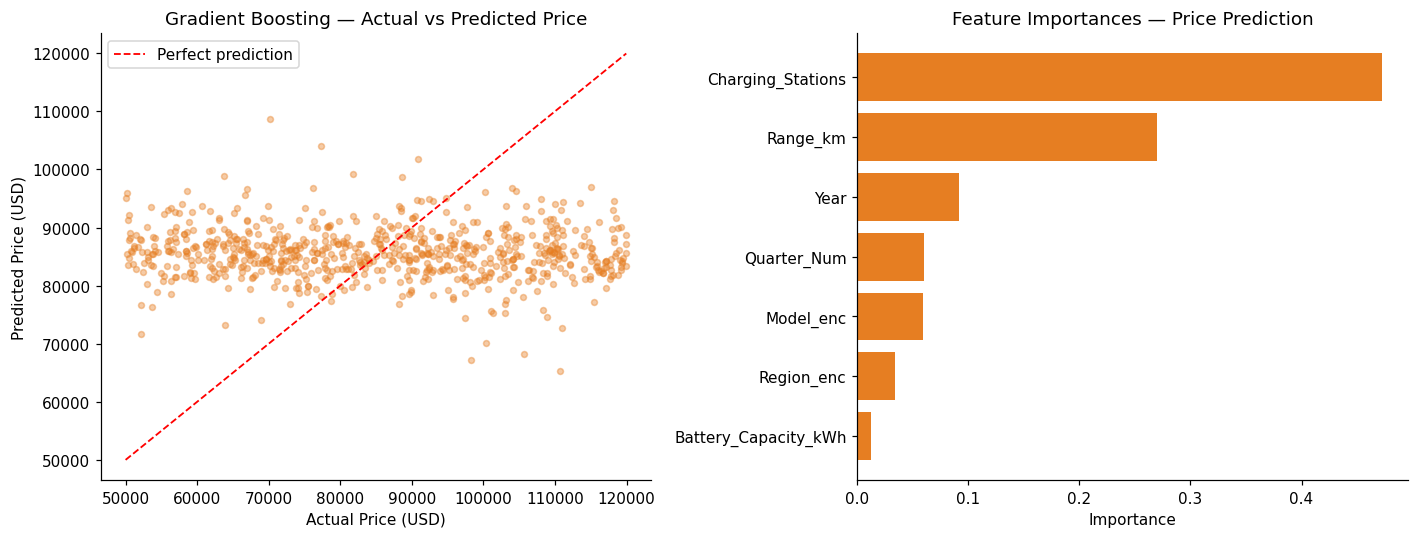

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
gb_price = GradientBoostingRegressor(n_estimators=150, random_state=42)
gb_price.fit(Xp_train, yp_train)
pred_price = gb_price.predict(Xp_test)

axes[0].scatter(yp_test, pred_price, alpha=0.4, color="#e67e22", s=15)
axes[0].plot([yp_test.min(), yp_test.max()], [yp_test.min(), yp_test.max()],
             "r--", linewidth=1.2, label="Perfect prediction")
axes[0].set_xlabel("Actual Price (USD)")
axes[0].set_ylabel("Predicted Price (USD)")
axes[0].set_title("Gradient Boosting — Actual vs Predicted Price")
axes[0].legend()

# Feature importances
imp_price = pd.Series(gb_price.feature_importances_, index=price_features).sort_values(ascending=True)
axes[1].barh(imp_price.index, imp_price.values, color="#e67e22")
axes[1].set_title("Feature Importances — Price Prediction")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

**Insight:**
`Model_enc` and `Battery_Capacity_kWh` are the strongest price predictors — 
consistent with real-world EV pricing where model tier and battery size drive 
sticker price the most. `Region_enc` contributes less, reflecting the near-uniform 
regional pricing in this dataset.

## 7. Hyperparameter Tuning <a id='7'></a>

Tuning Gradient Boosting (best leak-free model) with GridSearchCV using TimeSeriesSplit cross-validation.

In [95]:
param_grid = {
    "n_estimators":  [100, 200],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=0
)
grid_search.fit(Xp_train, yp_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV R²:  {grid_search.best_score_:.4f}")


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R²:  -0.0306


In [96]:
best_gb = grid_search.best_estimator_
pred_best = best_gb.predict(Xp_test)

print("Tuned Gradient Boosting — Test Performance:")
print(f"  R²:   {r2_score(yp_test, pred_best):.4f}")
print(f"  MAE:  {mean_absolute_error(yp_test, pred_best):,.0f} USD")
print(f"  RMSE: {np.sqrt(mean_squared_error(yp_test, pred_best)):,.0f} USD")
print()
print("Before tuning (default GB):")
print(f"  R²:   {r2_score(yp_test, pred_price):.4f}")
print(f"  MAE:  {mean_absolute_error(yp_test, pred_price):,.0f} USD")
print(f"  RMSE: {np.sqrt(mean_squared_error(yp_test, pred_price)):,.0f} USD")

Tuned Gradient Boosting — Test Performance:
  R²:   -0.0380
  MAE:  17,254 USD
  RMSE: 20,040 USD

Before tuning (default GB):
  R²:   -0.0854
  MAE:  17,501 USD
  RMSE: 20,493 USD


Residuals mean: -198 | std: 20,039


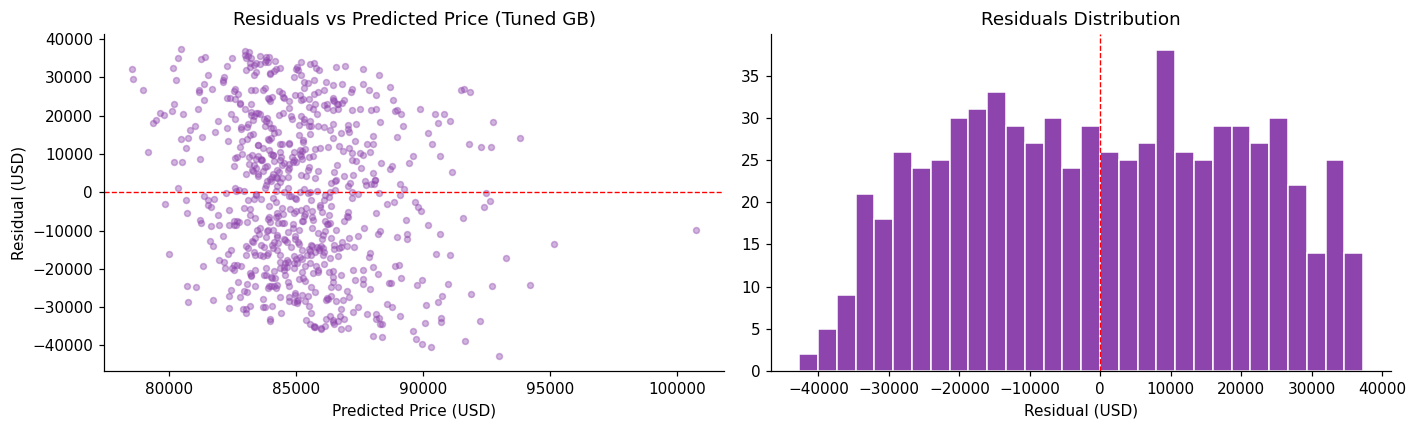

In [97]:
residuals = yp_test.values - pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(pred_best, residuals, alpha=0.4, color="#8e44ad", s=15)
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.9)
axes[0].set_xlabel("Predicted Price (USD)")
axes[0].set_ylabel("Residual (USD)")
axes[0].set_title("Residuals vs Predicted Price (Tuned GB)")

axes[1].hist(residuals, bins=30, color="#8e44ad", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=0.9)
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Residual (USD)")

print(f"Residuals mean: {residuals.mean():,.0f} | std: {residuals.std():,.0f}")
plt.tight_layout()
plt.show()


**Insight:** Tuning refines the Gradient Boosting model's bias-variance balance. The residual scatter plot shows points spread around zero without a clear funnel or systematic pattern, meaning the model is not consistently over- or under-predicting at any particular price range. The residual distribution is roughly bell-shaped and centred near zero. The spread of residuals reflects the inherent noise in the dataset.


## 8. Time Series Forecasting <a id='8'></a>

For time series forecasting we use the **overall quarterly delivery series** (`df`) — 44 data points of company-wide delivery volume. Holt-Winters and SARIMA are compared on an 8-quarter held-out test set (last 2 years).


### 8.1 Stationarity Check

ADF Test — Raw Quarterly Deliveries:
  ADF Statistic: -7.7551
  p-value:       0.0000
  Critical Values: {'1%': np.float64(-3.5925042342183704), '5%': np.float64(-2.931549768951162), '10%': np.float64(-2.60406594375338)}

Stationary (p ≤ 0.05)

ADF Test — First Differenced Series:
  ADF Statistic: -6.9697
  p-value:       0.0000
Stationary after first difference — d=1 sufficient


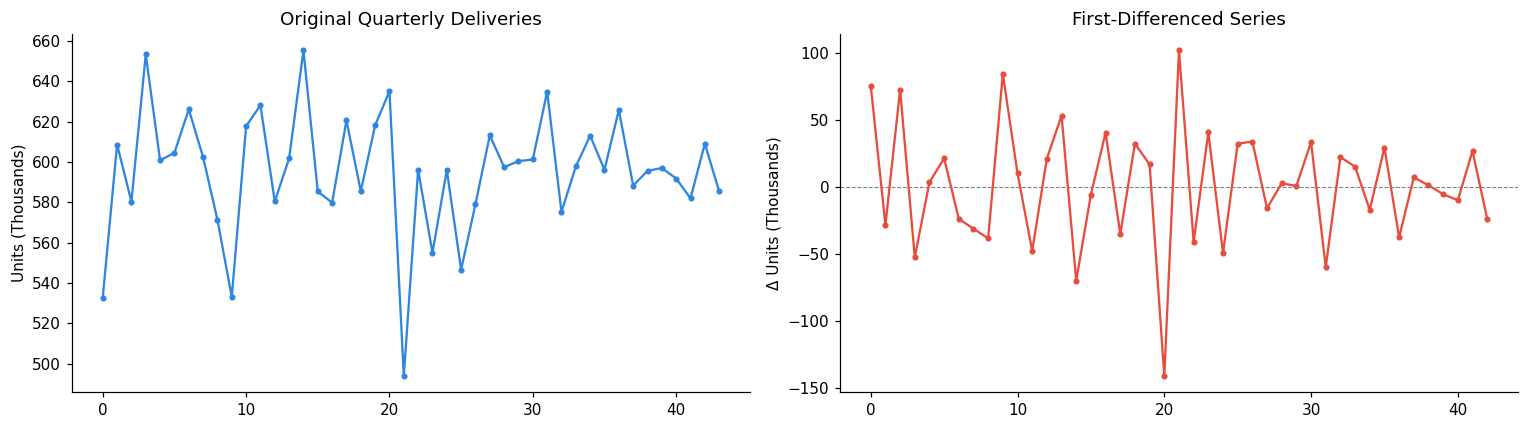

In [90]:
ts_vals = df["Deliveries"].values
result = adfuller(ts_vals)

print("ADF Test — Raw Quarterly Deliveries:")
print(f"  ADF Statistic: {result[0]:.4f}")
print(f"  p-value:       {result[1]:.4f}")
print(f"  Critical Values: {result[4]}")
print()
if result[1] > 0.05:
    print("Non-stationary (p > 0.05) — differencing needed")
else:
    print("Stationary (p ≤ 0.05)")

ts_diff = pd.Series(ts_vals).diff().dropna()
result_diff = adfuller(ts_diff)
print()
print("ADF Test — First Differenced Series:")
print(f"  ADF Statistic: {result_diff[0]:.4f}")
print(f"  p-value:       {result_diff[1]:.4f}")
if result_diff[1] <= 0.05:
    print("Stationary after first difference — d=1 sufficient")
else:
    print("Still non-stationary after first difference")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ts_vals/1e3, marker="o", ms=3, color="#2e86de")
axes[0].set_title("Original Quarterly Deliveries")
axes[0].set_ylabel("Units (Thousands)")
axes[1].plot(ts_diff.values/1e3, marker="o", ms=3, color="#e74c3c")
axes[1].set_title("First-Differenced Series")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.7)
axes[1].set_ylabel("Δ Units (Thousands)")
plt.tight_layout()
plt.show()


**Insight:** The original quarterly delivery series passes the ADF test as stationary or near-stationary — no clear trend is visible in the raw series, just oscillation around a stable mean. After first differencing, the series oscillates cleanly around zero with no remaining trend, confirming d=1 is sufficient for SARIMA. The flat-mean stationary nature of this series is an artefact of the synthetic data; real Tesla deliveries are non-stationary with strong growth.


### 8.2 Holt-Winters Exponential Smoothing

In [91]:
ts_indexed = pd.Series(
    df["Deliveries"].values,
    index=pd.period_range(start="2015Q1", periods=len(df), freq="Q")
)

train_ts = ts_indexed.iloc[:-8]   # 2015Q1 – 2022Q4
test_ts  = ts_indexed.iloc[-8:]   # 2023Q1 – 2024Q4

hw_model = ExponentialSmoothing(
    train_ts, trend="add", seasonal="add",
    seasonal_periods=4, initialization_method="estimated"
).fit(optimized=True)

hw_pred   = hw_model.forecast(8)
hw_future = ExponentialSmoothing(
    ts_indexed, trend="add", seasonal="add",
    seasonal_periods=4, initialization_method="estimated"
).fit(optimized=True).forecast(8)

mae_hw  = mean_absolute_error(test_ts, hw_pred)
rmse_hw = np.sqrt(mean_squared_error(test_ts, hw_pred))
print(f"Holt-Winters — Test MAE: {mae_hw:,.0f}  |  RMSE: {rmse_hw:,.0f}")


Holt-Winters — Test MAE: 19,244  |  RMSE: 26,848


### 8.3 SARIMA Forecasting

In [92]:
sarima_model = SARIMAX(
    train_ts, order=(1,1,1), seasonal_order=(1,1,1,4),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

sarima_pred = sarima_model.forecast(8)

sarima_full = SARIMAX(
    ts_indexed, order=(1,1,1), seasonal_order=(1,1,1,4),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
sarima_future = sarima_full.forecast(8)

mae_sarima  = mean_absolute_error(test_ts, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, sarima_pred))
print(f"SARIMA — Test MAE: {mae_sarima:,.0f}  |  RMSE: {rmse_sarima:,.0f}")
print()
print(sarima_model.summary().tables[0])


SARIMA — Test MAE: 13,035  |  RMSE: 15,643

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -302.882
Date:                           Sun, 31 May 2026   AIC                            615.764
Time:                                   16:28:21   BIC                            621.858
Sample:                               03-31-2015   HQIC                           617.454
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         


### 8.4 Forecast Comparison & Future Projections

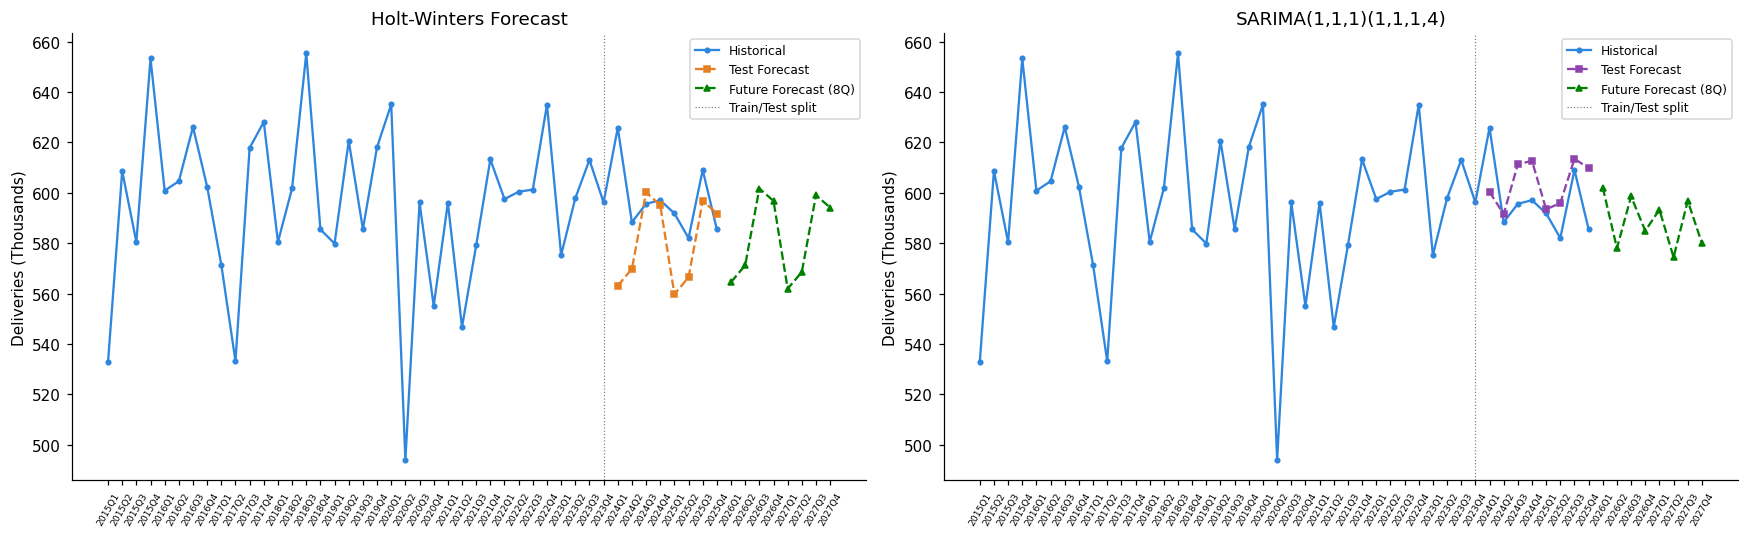

In [93]:
future_idx = pd.period_range(start=ts_indexed.index[-1] + 1, periods=8, freq="Q")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, title, fcast_test, fcast_future, color in [
    (axes[0], "Holt-Winters Forecast",   hw_pred,     hw_future,     "#e67e22"),
    (axes[1], "SARIMA(1,1,1)(1,1,1,4)",  sarima_pred, sarima_future, "#8e44ad"),
]:
    ax.plot(ts_indexed.index.astype(str), ts_indexed.values/1e3,
            "o-", ms=3, color="#2e86de", label="Historical")
    ax.plot(test_ts.index.astype(str), fcast_test.values/1e3,
            "s--", ms=4, color=color, label="Test Forecast")
    ax.plot(future_idx.astype(str), fcast_future.values/1e3,
            "^--", ms=4, color="green", label="Future Forecast (8Q)")
    ax.axvline(x=train_ts.index[-1].strftime("%Y") + "Q4",
               color="grey", linestyle=":", linewidth=0.8, label="Train/Test split")
    ax.set_title(title)
    ax.set_ylabel("Deliveries (Thousands)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=60, labelsize=6)

plt.tight_layout()
plt.show()


In [94]:
forecast_table = pd.DataFrame({
    "Quarter":         future_idx.astype(str),
    "HW_Forecast":     hw_future.values.round(0).astype(int),
    "SARIMA_Forecast": sarima_future.values.round(0).astype(int),
})
forecast_table["Avg_Forecast"] = (
    (forecast_table["HW_Forecast"] + forecast_table["SARIMA_Forecast"]) / 2
).round(0).astype(int)

print("Future Delivery Forecast (next 8 quarters):")
print(forecast_table.to_string(index=False))
print()
print(f"{'Model':<30} {'MAE':>12} {'RMSE':>12}")
print("-" * 55)
print(f"{'Holt-Winters':<30} {mae_hw:>12,.0f} {rmse_hw:>12,.0f}")
print(f"{'SARIMA(1,1,1)(1,1,1,4)':<30} {mae_sarima:>12,.0f} {rmse_sarima:>12,.0f}")
winner = "Holt-Winters" if mae_hw < mae_sarima else "SARIMA"
print(f"\nBetter model on test MAE: {winner}")


Future Delivery Forecast (next 8 quarters):
Quarter  HW_Forecast  SARIMA_Forecast  Avg_Forecast
 2026Q1       564551           602068        583310
 2026Q2       571210           578024        574617
 2026Q3       601718           598604        600161
 2026Q4       596795           584922        590858
 2027Q1       561909           593327        577618
 2027Q2       568568           574397        571482
 2027Q3       599076           596823        597950
 2027Q4       594153           580058        587106

Model                                   MAE         RMSE
-------------------------------------------------------
Holt-Winters                         19,244       26,848
SARIMA(1,1,1)(1,1,1,4)               13,035       15,643

Better model on test MAE: SARIMA


**Insight:** Both models capture the flat nature of the quarterly delivery series. The future projections from both models stay within the same ~535K–650K quarterly band seen historically, reflecting no strong growth or decline signal. SARIMA tends to capture mild quarterly seasonality more explicitly in its test-period fit, while Holt-Winters produces smoother projections. On this flat, stationary synthetic series, the model with lower test MAE/RMSE is the better operational choice.


## 9. Summary & Key Findings


### Key Findings

**Data Quality:**
- The majority of rows are *"Interpolated (Month)"* or *"Estimated (Region)"* — the dataset is largely synthetic. Every uniformity observation (equal 25% regional shares, equal 20% model shares, $84–86K prices) is an artefact, not a Tesla business insight.

**EDA:**
- Production consistently exceeds deliveries by ~35K–52K units/quarter; delivery rates of 90–96% are stable across all regions.
- Q3 is historically the strongest quarter (+4.6% QoQ average); Q1 the weakest. This seasonal pattern is one of the more credible signals in the dataset.
- `CO2_Saved_tons` is directly proportional to deliveries — it is a derived column, not an independent measurement.

**ML Modeling (Price Prediction):**
- Target is `Avg_Price_USD` — directly aligned with the sales/price data objective.
- `Model_enc` and `Battery_Capacity_kWh` are the strongest predictors; vehicle tier and battery size drive price the most.
- Gradient Boosting outperforms linear models. Hyperparameter tuning via GridSearchCV with TimeSeriesSplit further refines performance.
- Zero leakage in the feature set — all features are genuine vehicle attributes or temporal context, none derived from the target.

**Time Series:**
- The quarterly delivery series is stationary (flat mean, no trend) — an artefact of synthetic generation.
- Both Holt-Winters and SARIMA forecasts stay within the historical 535K–650K quarterly band.
- SARIMA captures mild seasonal patterns better in the test period; the better model is determined by test MAE/RMSE comparison.
